[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/apendice_f/apendice_f_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:19%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 1 Análise de Percepção e Avaliação Didática: PDI-VC 2026.2

Este apêndice apresenta uma análise **quantitativa e qualitativa, agregada e não identificável**, da percepção dos estudantes sobre a experiência pedagógica na disciplina de **Processamento Digital de Imagens e Visão Computacional (PDI-VC)**, oferecida no segundo quadrimestre de 2026. A apresentação dos resultados foi estruturada de modo a preservar a **confidencialidade e a não identificação dos participantes**, não sendo divulgados nomes, endereços eletrônicos, respostas individualizadas ou quaisquer outros elementos que permitam a identificação direta ou indireta de estudantes.

> ### 📝 Proteção da confidencialidade, tratamento dos dados e reprodutibilidade
>
> As análises apresentadas neste apêndice são realizadas exclusivamente sobre **dados agregados ou anonimizados**, utilizados para fins de avaliação e análise da experiência pedagógica. Os resultados são apresentados de forma coletiva, sem associação entre respostas e identidades individuais.
>
> As tabelas, estatísticas e gráficos são gerados de forma **automática e reprodutível** a partir dos dados utilizados na análise. O *notebook Colab* disponibilizado pelo ícone no canto superior esquerdo documenta os procedimentos computacionais empregados, incluindo o processamento, a transformação e a geração dos resultados apresentados neste apêndice.
>
> Os **dados brutos contendo informações potencialmente identificáveis não são publicados**, incorporados ao material de divulgação ou disponibilizados por meio do *notebook*. Da mesma forma, respostas individuais não são apresentadas de maneira que possibilite sua atribuição a participantes específicos. Eventuais materiais necessários à **auditoria metodológica** permanecem sob guarda do responsável pela pesquisa e poderão ser disponibilizados, quando cabível, exclusivamente em condições compatíveis com as exigências éticas aplicáveis e sem exposição de dados pessoais ou identificáveis.
>
> A identificação utilizada exclusivamente para o pareamento entre os questionários PRÉ e PÓS, quando necessária à análise longitudinal, não é divulgada nos resultados. Após a realização dos procedimentos analíticos que dependem desse pareamento, os resultados são apresentados de forma agregada, preservando-se a confidencialidade dos participantes.

## 1.1 Caracterização da Amostra e Metodologia de Coleta

A coleta de dados ocorreu em dois momentos do quadrimestre. O **questionário PRÉ-curso**, aplicado na primeira semana de aula, caracterizou o perfil dos estudantes antes da intervenção pedagógica. O **questionário PÓS-curso**, aplicado ao final do quadrimestre, após a utilização dos recursos didáticos e das estratégias analisadas neste apêndice, avaliou a experiência na disciplina e foi aplicado juntamente com a prova final.

Foram obtidas **104 respostas no PRÉ** e **80 no PÓS**. Com base nas informações fornecidas pelos estudantes para possibilitar a identificação entre os dois momentos, foram identificados **15 estudantes que responderam a ambos os questionários**, constituindo a **amostra pareada** utilizada na análise da evolução individual.

A distribuição dos respondentes entre as três turmas é apresentada na [Tabela 1.1](#tbl-contagem-turmas). As turmas **DA1** e **DA2** correspondem à graduação, oferecida no período **matutino**, enquanto a **MCC** corresponde à pós-graduação, oferecida no período **vespertino**. Entre o PRÉ e o PÓS, o número de respostas **manteve-se em 39 na DA1**, enquanto diminuiu de **46 para 30 na DA2** e de **19 para 11 na MCC**. Assim, a redução da amostra concentrou-se nas turmas **DA2 e MCC**, enquanto a participação da **DA1 permaneceu estável**.


Considerando a natureza ordinal das escalas *Likert* de cinco pontos, foram empregados **testes estatísticos não paramétricos**. O teste de *Mann--Whitney U* (MANN; WHITNEY, 1947) foi utilizado nas comparações entre amostras independentes; o teste de *Kruskal--Wallis* (KRUSKAL; WALLIS, 1952), nas comparações entre mais de dois grupos independentes; e o teste de Friedman (FRIEDMAN, 1937), na comparação entre diferentes recursos avaliados pelos mesmos estudantes. Para a comparação pareada entre PRÉ e PÓS, empregou-se o teste de *Wilcoxon* (WILCOXON, 1945).

Como complemento aos testes de significância, foram analisados **tamanhos de efeito**, **correlações de *Spearman***, **consistência interna pelo $\alpha$ de *Cronbach*** e **preferências declaradas**, permitindo uma interpretação mais ampla dos resultados.

> ### 📝 Nota Metodológica
>
> Os testes estatísticos permitem identificar diferenças e associações, mas não estabelecem relações causais. Assim, diferenças entre recursos que utilizaram ou não IA não devem ser interpretadas isoladamente como efeito da tecnologia, uma vez que esses recursos apresentam finalidades, formatos, níveis de interação e momentos de utilização distintos.

In [1]:
import os
import re
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# --------------------------------------------------------------------------
# CONFIGURAÇÃO: caminhos dos arquivos CSV locais na pasta dataset/
# --------------------------------------------------------------------------
PATH_POS = os.path.join("dataset", "POS_anonimizado.csv")
PATH_PRE = os.path.join("dataset", "PRE_anonimizado.csv")

# ==============================================================================
# PADRÃO VISUAL DO NOTEBOOK — usado em TODOS os gráficos a partir daqui.
# Qualquer ajuste de cor/estilo deve ser feito aqui, uma única vez.
# ==============================================================================
CORES = {
    "pre":            "#91bfdb",   # respostas do momento PRÉ
    "pos":            "#a6d96a",   # respostas do momento PÓS 
    "aprovado":       "#2b5c8f",   # item significativo / aprovado (azul escuro) 
    "neutro":         "#8c96c6",   # item não significativo (roxo acinzentado) 
    "linha_neutra":   "#d73027",   # linha de referência do ponto neutro (3,0) 
    "media_marker":   "#d73027",   # marcador de média em boxplots 
    "outlier":        "#e67e22",   # destaque de casos excluídos/atípicos 
    "likert_5cores":  ["#d7191c", "#fdae61", "#ffffbf", "#a6d96a", "#1a9641"],  # notas 1→5 
    "efeito_pequeno": "#3498db", 
    "efeito_medio":   "#e67e22", 
    "efeito_grande":  "#27ae60", 
    "efeito_nulo":    "#7f8c8d", 
    "heatmap_cmap":   "YlGnBu_r", 
    "texto_escuro":   "#111111", 
    "texto_medio":    "#333333", 
}
FONTE = {"titulo": 13, "subtitulo": 12, "eixo": 11, "texto": 9.5, "legenda": 9} 

sns.set_theme(style="whitegrid", context="notebook", palette="muted") 
plt.rcParams["figure.figsize"] = (10, 6) 
plt.rcParams["font.size"] = 10 
plt.rcParams["axes.titleweight"] = "bold" 

def extrair_descricao(col, max_len=90):
    """Extrai prioritariamente o texto contido dentro de colchetes [...] do cabeçalho do Forms.
    Se não houver colchetes com texto descritivo, limpa o texto do enunciado."""
    # Procura por conteúdos dentro de colchetes [...]
    m = re.findall(r'\[(.*?)\]', str(col))
    if m:
        # Filtra códigos simples como [Q08_02] para pegar o texto/rótulo completo do colchete
        # Exemplo: de "[Q09_02 - Simuladores]" pega "Q09_02 - Simuladores"
        textos = [t.strip() for t in m if len(t.strip()) > 0]
        if textos:
            # Seleciona o trecho entre colchetes mais informativo (o maior ou mais descritivo)
            desc = sorted(textos, key=len, reverse=True)[0]
            if len(desc) > max_len:
                desc = desc[:max_len - 1].rstrip() + "…"
            return desc

    # Fallback (caso não haja colchetes na coluna)
    desc = re.sub(r"\[+(PRE_Q\d+|Q\d+(?:_\d+)?)\]*", "", str(col)).strip(" -–:\u200b\"")
    desc = re.sub(r"^\d{1,2}[\.\)]\s*", "", desc)
    desc = re.sub(r"\s+", " ", desc).strip()
    if len(desc) > max_len:
        desc = desc[:max_len - 1].rstrip() + "…"
    return desc

def extrair_codigo(col):
    """Extrai um código curto tipo Q01, Q08_05, PRE_Q06 do cabeçalho longo do Forms."""
    m = re.search(r"\[+(PRE_Q\d+|Q\d+(?:_\d+)?)", col)
    if m:
        return m.group(1)
    if col.strip() == "" or col.startswith("[Q09"):
        return None  # coluna de checkbox sem rótulo (bug identificado) -> tratada à parte
    return col  # mantém original (ex.: Carimbo, Turma, e-mail)

def estilo_eixos(ax):
    """Acabamento padrão de todos os gráficos: remove as bordas superior e direita.""" 
    ax.spines["top"].set_visible(False) 
    ax.spines["right"].set_visible(False) 
    return ax 


def linha_neutra(ax, valor=3.0, orientacao="v", label="Ponto Neutro (3,0)"):
    """Desenha a linha de referência do ponto neutro da escala, com o estilo padrão.""" 
    if orientacao == "v": 
        ax.axvline(valor, color=CORES["linha_neutra"], linestyle="--", linewidth=1.5, alpha=0.85, label=label) 
    else:
        ax.axhline(valor, color=CORES["linha_neutra"], linestyle="--", linewidth=1.5, alpha=0.85, label=label) 

In [2]:
# @title { display-mode: "form" }
# --------------------------------------------------------------------------
# Opções de chunk usadas aqui:
#   echo: false     -> esconde o código, mantém o output (tabela/gráfico)
#   include: false  -> esconde código E output, mas ainda executa (setup/imports)
#   output: false   -> mostra o código, esconde só o output
# --------------------------------------------------------------------------

import json
import os

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS
# ==============================================================================
def carregar_pipeline():
    """Carrega PRÉ e PÓS anonimizados do zero e normaliza a coluna Turma
    (funde grafias divergentes como 'CCM'/'MCC')."""

    def _carregar(caminho_csv):
        df = pd.read_csv(caminho_csv)
        df.columns = [str(c).strip() for c in df.columns]
        return df

    def _normalizar_turmas(df, coluna="Turma", mapeamento=None):
        """Normaliza grafias divergentes da coluna Turma (ex.: 'CCM' e 'MCC' são a
        mesma turma, só com a sigla do curso invertida). Aplica strip + upper antes
        de mapear, para pegar também variações de espaço/caixa (' mcc', 'Mcc' etc.)."""
        if mapeamento is None:
            mapeamento = {"CCM": "MCC"}  # ajuste aqui se o canônico deveria ser CCM
        df = df.copy()
        turma_normalizada = df[coluna].astype(str).str.strip().str.upper()
        df[coluna] = turma_normalizada.replace(mapeamento)
        return df

    pos = _carregar(PATH_POS)
    pre = _carregar(PATH_PRE)
    pos = _normalizar_turmas(pos)
    pre = _normalizar_turmas(pre)

    print("PÓS -> colunas:", pos.shape[1], "| respondentes:", pos.shape[0])
    print("PRÉ -> colunas:", pre.shape[1], "| respondentes:", pre.shape[0])

    return pos, pre


pos, pre = carregar_pipeline()

# ==============================================================================
# 2. METADADOS DAS PERGUNTAS (rótulos + enunciados completos)
# ==============================================================================
# Gerado pelo sigilo.py a partir dos headers originais do Forms (antes da
# anonimização). É a única fonte de verdade; não há mais extração manual nem
# tentativa de extrair dos CSVs anonimizados, já que dataset/*_anonimizado.csv
# só tem colunas curtas (Q01, Q02...), sem texto de header sobrando.
with open(os.path.join("dataset", "metadados_perguntas.json"), encoding="utf-8") as f:
    METADADOS_PERGUNTAS = json.load(f)

# Overrides manuais — só para itens que o Forms não etiqueta com rótulo entre
# colchetes (perguntas abertas de texto livre). Deixe vazio se não houver
# nenhuma exceção pendente.
DESCRICOES_OVERRIDE = {
    "Q14": "Maior contribuição da IA",
    "Q15": "Dificuldades e ajustes metodológicos",
}

DESCRICOES = {
    cod: DESCRICOES_OVERRIDE.get(cod) or info.get("rotulo") or cod
    for cod, info in METADADOS_PERGUNTAS.items()
}
ENUNCIADOS_COMPLETOS = {
    cod: info.get("enunciado")
    for cod, info in METADADOS_PERGUNTAS.items()
    if info.get("enunciado")
}

print(f"{len(DESCRICOES)} rótulos e {len(ENUNCIADOS_COMPLETOS)} enunciados carregados de metadados_perguntas.json.")
assert len(DESCRICOES) >= 25, f"Só {len(DESCRICOES)} rótulos disponíveis — confira dataset/metadados_perguntas.json."

# ==============================================================================
# 3. FUNÇÕES AUXILIARES DE TABELA
# ==============================================================================
def tabela_itens_md(codigos, coluna_texto="Enunciado aplicado"):
    """Monta um DataFrame Item/Texto para uma lista de códigos, usando os
    rótulos e enunciados já carregados de metadados_perguntas.json."""
    linhas = [
        {"Item": f"`{cod}`", coluna_texto: f"**{DESCRICOES.get(cod, cod)}:** {ENUNCIADOS_COMPLETOS.get(cod, '—')}"}
        for cod in codigos
    ]
    return pd.DataFrame(linhas)


def extrair_opcoes_q09(serie_q09):
    """Varre as respostas de Q09 (texto livre com múltiplas seleções, no formato
    '[Q09_XX - Rótulo] Descrição, [Q09_YY - Rótulo] Descrição, ...') e monta
    automaticamente código -> (rótulo curto, descrição completa), agregando o
    conjunto de opções que aparece em qualquer linha de resposta."""
    opcoes = {}
    for valor in serie_q09.dropna():
        partes = re.split(r",\s*(?=\[Q09_)", str(valor))
        for parte in partes:
            m = re.match(r"\[(Q09_\d{2})\s*-\s*([^\]]+)\]\s*(.*)", parte.strip())
            if m:
                cod, rotulo, desc = m.groups()
                if cod not in opcoes:
                    opcoes[cod] = (rotulo.strip(), desc.strip().rstrip(","))
    return opcoes

def fmt_num_br(x, casas=3):
    """Formata número no padrão brasileiro (vírgula decimal). Medianas de escala
    Likert (1-5) costumam ser inteiras, mas o formato se adapta caso não sejam."""
    if pd.isna(x):
        return "—"
    if casas == 0 or float(x).is_integer():
        return str(int(round(x)))
    return f"{x:.{casas}f}".replace(".", ",")


def fmt_p_br(p):
    if pd.isna(p):
        return "—"
    return "<0,001" if p < 0.001 else f"{p:.3f}".replace(".", ",")

OPCOES_Q09 = extrair_opcoes_q09(pos["Q09"])
print(f"{len(OPCOES_Q09)} opções de Q09 identificadas automaticamente (esperado: 10).")

display(pos.head())

PÓS -> colunas: 28 | respondentes: 80
PRÉ -> colunas: 20 | respondentes: 104
31 rótulos e 31 enunciados carregados de metadados_perguntas.json.
10 opções de Q09 identificadas automaticamente (esperado: 10).


,ID_Anonimo,Carimbo de data/hora,Turma,Q01,Q02,Q03,Q04,Q05,Q06,Q07,Q08_01,Q08_02,Q08_03,Q08_04,Q08_05,Q08_06,Q08_07,Q08_08,Q08_09,Q08_10,Q08_11,Q09,Q10,Q11,Q12,Q13,Q14,Q15
0,Aluno_NA_POS_01,09/08/2026 20:00:04,DA1,3,4,4,3,3,5,4,4,3,4,5,5,3,3,3,1,4,5,[Q09_03 - EPs em Aula] Resolução dos Exercício...,4,3,3,3,NaN,NaN
1,Aluno_POS_01,09/08/2026 20:06:08,DA2,4,3,4,4,5,5,4,5,5,5,4,5,5,5,3,5,5,5,[Q09_02 - Simuladores] Simuladores interativos...,4,4,4,4,NaN,NaN
2,Aluno_POS_02,09/08/2026 20:11:04,DA2,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,[Q09_02 - Simuladores] Simuladores interativos...,5,4,4,4,NaN,NaN
3,Aluno_NA_POS_02,09/08/2026 20:11:44,DA2,5,1,1,2,3,4,3,2,1,2,4,4,3,4,3,4,4,5,[Q09_03 - EPs em Aula] Resolução dos Exercício...,3,3,3,3,NaN,NaN
4,Aluno_POS_03,09/08/2026 20:13:25,DA1,5,5,5,3,4,3,5,4,2,5,5,4,4,4,3,5,5,4,[Q09_02 - Simuladores] Simuladores interativos...,3,5,2,1,NaN,NaN


In [3]:
# @title { display-mode: "form" }
from IPython.display import Markdown

# 1. Contagem de respondentes por turma em cada momento (PRÉ / PÓS)
contagem_pre = pre["Turma"].value_counts()
contagem_pos = pos["Turma"].value_counts()

turmas = sorted(set(contagem_pre.index) | set(contagem_pos.index))

# 2. Monta as linhas da tabela, turma a turma
resultados_turmas = [
    {
        "Turma": turma,
        "PRÉ (n)": int(contagem_pre.get(turma, 0)),
        "PÓS (n)": int(contagem_pos.get(turma, 0)),
    }
    for turma in turmas
]

# 3. Linha de Total, em negrito (markdown), ao final
total_pre = sum(r["PRÉ (n)"] for r in resultados_turmas)
total_pos = sum(r["PÓS (n)"] for r in resultados_turmas)
resultados_turmas.append({
    "Turma": "**Total**",
    "PRÉ (n)": f"**{total_pre}**",
    "PÓS (n)": f"**{total_pos}**",
})

df_turmas = pd.DataFrame(resultados_turmas)
#print(f"Turmas identificadas: {', '.join(turmas)}\n")
#print(f"Total de respondentes — PRÉ: {total_pre} | PÓS: {total_pos}\n")
Markdown(df_turmas.to_markdown(index=False, colalign=("left", "center", "center")))

**Tabela 1.1:** Quantidade de respondentes por turma nos questionários PRÉ e PÓS.


| Turma     |  PRÉ (n)  |  PÓS (n)  |
|:----------|:---------:|:---------:|
| DA1       |    39     |    39     |
| DA2       |    46     |    30     |
| MCC       |    19     |    11     |
| **Total** |  **104**  |  **80**   |

## 1.2 Itens do questionário PÓS

O questionário PÓS foi estruturado em cinco blocos. O **Bloco 1** reúne a identificação opcional do estudante e a seleção de uma das três turmas. O **Bloco 2**, apresentado na [Tabela 1.2](#tbl-pos-bloco2), aborda a **autopercepção de aprendizado e desempenho**. O **Bloco 3**, apresentado na [Tabela 1.3](#tbl-pos-bloco3) (`Q08`) e na [Tabela 1.4](#tbl-pos-q09) (`Q09`), avalia os **recursos didáticos**. O **Bloco 4**, apresentado na [Tabela 1.5](#tbl-pos-bloco4), investiga a percepção sobre a **integração da Inteligência Artificial (IA)** ao processo de ensino e aprendizagem. Por fim, o **Bloco 5**, apresentado na [Tabela 1.6](#tbl-pos-bloco5), reúne duas questões abertas.

Os itens avaliativos dos Blocos 2, 3 e 4 utilizam uma **escala *Likert* de cinco pontos**: 1 = *Discordo totalmente*; 2 = *Discordo*; 3 = *Indiferente*; 4 = *Concordo*; e 5 = *Concordo totalmente*. A questão `Q09`, pertencente ao Bloco 3, adota formato distinto, solicitando a **seleção de exatamente quatro recursos** considerados mais eficazes para a aprendizagem pelo estudante.

### 1.2.1 Itens do Bloco 2 — Autopercepção de Aprendizado e Desempenho

A [Tabela 1.2](#tbl-pos-bloco2) apresenta os sete itens do Bloco 2, que avaliam a **autopercepção dos estudantes sobre o aprendizado e o desempenho** ao final da disciplina. Os seis primeiros itens abrangem capacidade de programação, aplicação dos conhecimentos em outras disciplinas e na atuação profissional, fundamentos matemáticos, autonomia no uso de bibliotecas e percepção sobre o *feedback* por IA. Esses itens possuem correspondência com questões do questionário **PRÉ** e serão analisados de forma pareada na seção seguinte, permitindo avaliar a evolução das percepções individuais. O item `Q07` apresenta uma avaliação global da evolução dos conhecimentos teóricos e práticos em PDI-VC ao longo da disciplina.

In [4]:
codigos_bloco2 = ["Q01", "Q02", "Q03", "Q04", "Q05", "Q06", "Q07"]
df_bloco2 = tabela_itens_md(codigos_bloco2)
Markdown(df_bloco2.to_markdown(index=False, colalign=("left", "left")))

**Tabela 1.2:** Itens do Bloco 2 — Autopercepção de Aprendizado e Desempenho.


| Item   | Enunciado aplicado                                                                                                                                                                                      |
|:-------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Q01`  | **PÓS - Capacidade de Programação:** Atualmente, consigo resolver problemas computacionais básicos usando programação.                                                                                  |
| `Q02`  | **PÓS - Atuação Acadêmica:** Os conhecimentos desenvolvidos nesta disciplina têm me ajudado na minha atuação acadêmica em outras disciplinas.                                                           |
| `Q03`  | **PÓS - Atuação Profissional:** Os conhecimentos desenvolvidos nesta disciplina serão úteis para a minha atuação profissional                                                                           |
| `Q04`  | **PÓS - Fundamentos Matemáticos:** Atualmente, considero que minha base em Álgebra Linear e Cálculo (conceitos usados em PDI) é muito boa.                                                              |
| `Q05`  | **PÓS - Autonomia com Bibliotecas:** Atualmente, sinto que tenho boa autonomia para utilizar bibliotecas de processamento de dados/imagens (ex: OpenCV, NumPy, Matplotlib, morph.py).                   |
| `Q06`  | **PÓS - Feedback por IA:** Atualmente, considero útil o feedback automático de código gerado por IA.                                                                                                    |
| `Q07`  | **GLOBAL_BLOCO2 - Avaliação Geral do Aprendizado:** De forma geral, considero que o meu nível de conhecimento teórico e prático na área de PDI-VC evoluiu significativamente ao longo desta disciplina. |

### 1.2.2 Itens do Bloco 3 — Recursos Didáticos

O **Bloco 3** avalia os recursos didáticos utilizados na disciplina. É composto por dez itens de avaliação (`Q08_01`--`Q08_10`), apresentados na [Tabela 1.3](#tbl-pos-bloco3); uma questão sobre o acesso ao VPL (`Q08_11`); uma questão de **preferência pelos recursos** (`Q09`); e uma **avaliação global** (`Q10`).

In [5]:
# @title { display-mode: "form" }
codigos_bloco3 = [f"Q08_{i:02d}" for i in range(1, 12)] + ["Q09", "Q10"]
df_bloco3 = tabela_itens_md(codigos_bloco3)
Markdown(df_bloco3.to_markdown(index=False, colalign=("left", "left")))

**Tabela 1.3:** Itens do Bloco 3 — Recursos Didáticos.


| Item     | Enunciado aplicado                                                                                                                                                                                                                                                                       |
|:---------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Q08_01` | **Livro Interativo:** O uso do Livro Interativo (HTML/IPYNB/PDF) com simuladores e teoria integrada contribuiu significativamente para o meu aprendizado.                                                                                                                                |
| `Q08_02` | **Material Didático por IA:** Os vídeos curtos (~7 min) e os slides (~12 slides) produzidos via Gemini Notebook ajudaram a introduzir e sintetizar o conteúdo antes do início da aula prática no Colab                                                                                   |
| `Q08_03` | **Simuladores Interativos:** A manipulação visual de parâmetros em tempo real nos simuladores interativos (no HTML/Colab) facilitou a compreensão dos algoritmos.                                                                                                                        |
| `Q08_04` | **Resolução de EPs em Aula:** A resolução acompanhada dos Exercícios de Programação (EPs) durante o horário de aula foi fundamental para o meu desempenho prático.                                                                                                                       |
| `Q08_05` | **Biblioteca morph.py:** O uso da biblioteca didática morph.py (com implementações didáticas como mm.dil0 e otimizadas) tornou o código dos algoritmos mais transparente e compreensível.                                                                                                |
| `Q08_06` | **Provas e Simulados Paramétricos:** As avaliações parametrizadas pelo MCTest e aplicadas via SEB (com questões individuais) foram eficazes para avaliar meu aprendizado de forma justa.                                                                                                 |
| `Q08_07` | **Feedback Socrático no VPL:** O feedback qualitativo/socrático gerado por IA ao pedir avaliação do código nos EPs do VPL/Moodle ajudou a identificar e corrigir erros na minha lógica.                                                                                                  |
| `Q08_08` | **Rubrica por IA em Simulados/Provas:** O relatório enviado por e-mail com a rubrica detalhada por IA e o resumo comparativo agregou valor ao meu processo de revisão das provas e simulados.                                                                                            |
| `Q08_09` | **Correção Objetiva VPL:** A validação automática objetiva por casos de teste no VPL/Moodle deu um retorno rápido e claro sobre o funcionamento do código.                                                                                                                               |
| `Q08_10` | **Uso do TestSuite.py:** O testsuite.py facilitou testar meus EPs no Colab antes de submeter no VPL.                                                                                                                                                                                     |
| `Q08_11` | **VPL só na UFABC:** O bloqueio de acesso ao VPL fora da rede da UFABC dificultou meus estudos.                                                                                                                                                                                          |
| `Q09`    | **Ranking de Preferência:** Escolha até 4 recursos que considerou MAIS EFICAZES no seu processo de estudo:                                                                                                                                                                               |
| `Q10`    | **GLOBAL_BLOCO3 - Avaliação Geral dos Recursos Didáticos:** Em conjunto, o ecossistema de recursos metodológicos oferecidos nesta disciplina (livro interativo, materiais multimídia por IA, simuladores, biblioteca didática e avaliações) foi altamente eficaz para o meu aprendizado. |

A questão `Q09` utilizou um formato de **seleção de preferência**, no qual cada estudante deveria selecionar **exatamente quatro recursos** considerados mais eficazes para seu processo de estudo. A questão apresentou **dez opções de recursos**, relacionadas na [Tabela 1.4](#tbl-pos-q09).

In [6]:
# @title { display-mode: "form" }
linhas_q09 = [
    {"Item": f"`{cod}`", "Recurso": f"**{rotulo}:** {desc}"}
    for cod, (rotulo, desc) in sorted(OPCOES_Q09.items())
]
df_q09 = pd.DataFrame(linhas_q09)
Markdown(df_q09.to_markdown(index=False, colalign=("left", "left")))

**Tabela 1.4:** Opções apresentadas na questão `Q09` — *Ranking* agregado por frequência de seleção.


| Item     | Recurso                                                                                                            |
|:---------|:-------------------------------------------------------------------------------------------------------------------|
| `Q09_01` | **Gemini Audio/Visual:** Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook)          |
| `Q09_02` | **Simuladores:** Simuladores interativos (manipulação de parâmetros)                                               |
| `Q09_03` | **EPs em Aula:** Resolução dos Exercícios de Programação (EPs) em sala de aula                                     |
| `Q09_04` | **Livro Interativo:** Livro interativo no formato HTML / Colab                                                     |
| `Q09_05` | **morph.py:** Biblioteca didática morph.py                                                                         |
| `Q09_06` | **IA Feedback VPL:** Feedback socrático por IA a cada submissão de código no VPL/Moodle                            |
| `Q09_07` | **IA Rubrica Provas:** Feedback por e-mail com rubrica de avaliação qualitativa gerada por IA nos Simulados/Provas |
| `Q09_08` | **SEB Simulados:** Simulados quinzenais em laboratório (SEB)                                                       |
| `Q09_09` | **VPL Casos Teste:** Validação objetiva por casos de teste no VPL                                                  |
| `Q09_10` | **TestSuite.py:** Uso do testsuite.py no Colab para testar EPs localmente                                          |

### 1.2.3 Itens do Bloco 4 — Avaliação Específica do Uso Transversal da Inteligência Artificial

Os itens `Q11`--`Q13`, apresentados na [Tabela 1.5](#tbl-pos-bloco4), avaliam a percepção dos estudantes sobre a **integração transversal da Inteligência Artificial (IA)** no processo de ensino e aprendizagem. Como utilizam a mesma escala *Likert* de cinco pontos descrita anteriormente, esses itens compõem, juntamente com os demais itens ordinais, a síntese dos **21 itens *Likert*** apresentada ao final deste apêndice.

O item `Q08_11` e a questão `Q09`, pertencentes ao **Bloco 3**, não integram essa síntese, pois apresentam formatos e finalidades distintos da avaliação ordinal dos recursos didáticos. O `Q08_11` investiga uma dificuldade específica relacionada ao acesso ao VPL, enquanto `Q09` utiliza **seleção de exatamente quatro recursos**, sem estabelecer ordenação entre as alternativas.

In [7]:
# @title { display-mode: "form" }
codigos_bloco4 = ["Q11", "Q12", "Q13"]
df_bloco4 = tabela_itens_md(codigos_bloco4)
Markdown(df_bloco4.to_markdown(index=False, colalign=("left", "left")))

**Tabela 1.5:** Itens do Bloco 4 — Avaliação Específica do Uso Transversal da Inteligência Artificial


| Item   | Enunciado aplicado                                                                                                                                                                                          |
|:-------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Q11`  | **Pensamento Crítico e Alucinações:** Perceber eventuais limitações ou imprecisões nas explicações da IA (no feedback ou materiais) estimulou meu senso crítico sobre a correção do código.                 |
| `Q12`  | **Transversalidade Pedagógica:** Recomendo que essa abordagem integrada de IA (produção de material + feedback socrático no VPL + rubrica qualitativa em provas) seja adotada em outras disciplinas.        |
| `Q13`  | **GLOBAL_BLOCO4 - Avaliação Geral da Integração de IA:** O uso transversal e transparente de Inteligência Artificial ao longo da disciplina agregou valor significativo à minha experiência de aprendizado. |

### 1.2.4 Bloco 5 — Questões Abertas

O **Bloco 5** reúne duas questões abertas e opcionais, apresentadas na [Tabela 1.6](#tbl-pos-bloco5), destinadas a complementar a avaliação quantitativa com *feedback* qualitativo sobre a experiência dos estudantes com a metodologia da disciplina e, especificamente, sobre o uso da **Inteligência Artificial (IA)** no processo de ensino e aprendizagem.

In [8]:
# @title { display-mode: "form" }
codigos_bloco5 = ["Q14", "Q15"]
df_bloco5 = tabela_itens_md(codigos_bloco5)
Markdown(df_bloco5.to_markdown(index=False, colalign=("left", "left")))

**Tabela 1.6:** Itens do Bloco 5 — Questões Abertas.


| Item   | Enunciado aplicado                                                                                                                                                                                              |
|:-------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Q14`  | **Maior contribuição da IA:** Dentre os usos da IA nesta disciplina (geração de material, feedback socrático nos EPs, rubrica nos simulados/provas), qual trouxe o maior ganho para o seu aprendizado? Por quê? |
| `Q15`  | **Dificuldades e ajustes metodológicos:** Qual elemento da metodologia (SEB, MCTest, tempo de prova, feedback por IA, biblioteca) apresentou maior dificuldade ou precisará de ajustes nas próximas ofertas?    |

As questões `Q14` e `Q15` não utilizaram escala ordinal nem alternativas predefinidas. As respostas, de caráter **aberto e opcional**, permitiram aos estudantes registrar livremente suas percepções, justificativas, dificuldades e sugestões de melhoria. Por esse motivo, esses itens não integram as análises estatísticas baseadas nas questões *Likert* e são examinados separadamente por meio de **codificação temática** e **classificação de valência**, apresentadas nas seções seguintes.

## 1.3 Perfil acadêmico dos participantes

A interpretação dos resultados deve considerar o **perfil acadêmico dos participantes**, especialmente a composição da amostra de graduação, formada majoritariamente por estudantes em **etapas avançadas da formação**. No questionário PRÉ, **88 estudantes indicaram Ciência da Computação** e **30, Ciência de Dados** como cursos que estavam cursando ou pretendiam cursar após o Bacharelado Interdisciplinar. Como era permitida a seleção de mais de uma opção, esses quantitativos não são mutuamente exclusivos, conforme apresentado na [Tabela 1.7](#tbl-formacao-graduacao).

Essa composição ajuda a contextualizar a elevada autopercepção de **capacidade de programação** (`Q01`) observada no PRÉ e no PÓS, analisada nas subseções seguintes. Por outro lado, **Processamento Digital de Imagens (PDI) não constitui componente obrigatório da matriz curricular de todos esses cursos**; portanto, a formação acadêmica não permite presumir experiência prévia específica nessa área.

Na **pós-graduação**, observa-se maior diversidade nas formações de origem, incluindo Física, Engenharia Biomédica, Matemática, Ciências Atuariais, Biotecnologia, Computação e Ciência de Dados. Essa heterogeneidade corresponde a trajetórias acadêmicas distintas e pode estar associada a diferentes níveis de experiência prévia em programação e processamento de imagens.

Assim, a elevada autopercepção de **capacidade de programação** no PRÉ (ver [Tabela 1.8](#tbl-pre-pos-wilcoxon)) deve ser interpretada considerando a composição da amostra. A concentração de estudantes de graduação em etapas avançadas da formação pode ter contribuído para um possível **efeito teto** em `Q01`, cuja percepção já era elevada no início da disciplina e permaneceu em nível alto nos dois momentos.

In [9]:
# @title { display-mode: "form" }
def contar_selecoes_multiplas(serie, separador=","):
    """Conta a frequência de cada opção numa coluna de múltipla seleção do Forms,
    no formato 'Opção A, Opção B, Opção C'. Cada resposta pode conter 0+ opções."""
    contagem = {}
    for valor in serie.dropna().astype(str):
        for item in valor.split(separador):
            item = item.strip()
            if item:
                contagem[item] = contagem.get(item, 0) + 1
    return contagem


col_cursos_candidatos = [c for c in pre.columns if "curso" in c.lower() and "bacharelado" in c.lower()]
assert col_cursos_candidatos, "Coluna de cursos não encontrada em pre.columns — confira o nome exato do header no CSV."
col_cursos = col_cursos_candidatos[0]

contagem_cursos = contar_selecoes_multiplas(pre[col_cursos])
n_total_pre = len(pre)  # 104 — denominador fixo, conforme nota da tabela

cursos_frequentes = {c: n for c, n in contagem_cursos.items() if n > 1}
cursos_unicos = sorted(c for c, n in contagem_cursos.items() if n == 1)

resultados_cursos = [
    {
        "Curso/área indicada": curso,
        "Estudantes (n)": n,
        "Percentual*": f"{n / n_total_pre:.1%}".replace(".", ","),
    }
    for curso, n in sorted(cursos_frequentes.items(), key=lambda x: -x[1])
]

if cursos_unicos:
    resultados_cursos.append({
        "Curso/área indicada": "Outros (1 estudante cada): " + ", ".join(cursos_unicos),
        "Estudantes (n)": len(cursos_unicos),
        "Percentual*": f"{1 / n_total_pre:.1%}".replace(".", ",") + " cada",
    })

df_cursos = pd.DataFrame(resultados_cursos)
Markdown(df_cursos.to_markdown(index=False, colalign=("left", "center", "center")))

**Tabela 1.7:** Cursos indicados pelos estudantes de graduação. Percentuais calculados sobre os 104 respondentes. Como a questão permitia múltiplas respostas, os percentuais não são mutuamente exclusivos e podem somar mais de 100%.


| Curso/área indicada                                                                                                                                                                                        |  Estudantes (n)  |  Percentual*  |
|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------:|:-------------:|
| Ciência da Computação                                                                                                                                                                                      |        88        |     84,6%     |
| Ciência de Dados                                                                                                                                                                                           |        30        |     28,8%     |
| Instrumentação                                                                                                                                                                                             |        8         |     7,7%      |
| Automação e Robótica                                                                                                                                                                                       |        8         |     7,7%      |
| Matemática                                                                                                                                                                                                 |        6         |     5,8%      |
| Informação                                                                                                                                                                                                 |        6         |     5,8%      |
| Biomédica                                                                                                                                                                                                  |        5         |     4,8%      |
| Física                                                                                                                                                                                                     |        4         |     3,8%      |
| Neurociência                                                                                                                                                                                               |        3         |     2,9%      |
| Gestão                                                                                                                                                                                                     |        2         |     1,9%      |
| Outros (1 estudante cada): Aeroespacial, Ambiental e Urbana, Biotecnologia, Ciências Atuariais, Ciências Biológicas, Ciências atuariais, Energia, Filosofia, Pós em Ciência da Computação, formado em 1997 |        10        |   1,0% cada   |

## 1.4 Comparação entre os Questionários PRÉ e PÓS

A comparação entre os questionários **PRÉ** e **PÓS** busca identificar mudanças nas percepções dos estudantes ao longo da disciplina. A análise contempla seis dimensões: capacidade de programação, *feedback* por IA, atuação acadêmica, atuação profissional, fundamentos matemáticos e autonomia no uso de bibliotecas.

Para avaliar essas dimensões, foram empregados dois procedimentos complementares. O teste de *Wilcoxon* foi aplicado aos **15 estudantes pareados**, permitindo avaliar mudanças nas percepções individuais. O teste de *Mann--Whitney U* foi aplicado às **amostras completas**, permitindo verificar diferenças na distribuição das respostas entre os dois momentos. Dessa forma, o primeiro procedimento avalia **mudanças intraindividuais**, enquanto o segundo identifica **diferenças entre as amostras**, cuja composição não é necessariamente a mesma.

### 1.4.1 Evolução da Percepção dos Estudantes: PRÉ versus PÓS

A comparação entre os questionários **PRÉ** e **PÓS** busca identificar mudanças nas percepções dos estudantes ao longo da disciplina. Foram obtidas **104 respostas no PRÉ** e **80 no PÓS**, com **15 estudantes identificados nos dois momentos**, constituindo a amostra pareada utilizada na análise da evolução individual.

A análise contempla seis dimensões:

* **Capacidade de programação** (`PRE_Q01 → Q01`);
* ***Feedback* por IA** (`PRE_Q02 → Q06`);
* **Atuação acadêmica** (`PRE_Q03 → Q02`);
* **Atuação profissional** (`PRE_Q04 → Q03`);
* **Fundamentos matemáticos** (`PRE_Q05 → Q04`);
* **Autonomia com bibliotecas** (`PRE_Q06 → Q05`).

As médias e medianas apresentadas na [Tabela 1.8](#tbl-pre-pos-wilcoxon) referem-se às **amostras completas** (PRÉ $N=104$; PÓS $N=80$) e têm finalidade exclusivamente descritiva, correspondendo aos mesmos valores apresentados na [Tabela 1.9](#tbl-pre-pos-mw). A evolução individual foi avaliada pelo teste de *Wilcoxon*, aplicado aos **15 estudantes pareados**. Como esse teste é baseado nas diferenças ordenadas entre as observações, a **mediana** é apresentada juntamente com a média, permitindo uma interpretação mais adequada da tendência central em conjunto com o resultado inferencial.

In [10]:
# @title { display-mode: "form" }
MAPEAMENTO_PRE_POS = [
    ("Capacidade de programação", "PRE_Q01", "Q01"),
    ("Feedback por IA",           "PRE_Q02", "Q06"),
    ("Atuação acadêmica",         "PRE_Q03", "Q02"),
    ("Atuação profissional",      "PRE_Q04", "Q03"),
    ("Fundamentos matemáticos",   "PRE_Q05", "Q04"),
    ("Autonomia com bibliotecas", "PRE_Q06", "Q05"),
]


def fmt_num_br(x, casas=3):
    """Formata número no padrão brasileiro (vírgula decimal). Medianas de escala
    Likert (1-5) costumam ser inteiras, mas o formato se adapta caso não sejam."""
    if pd.isna(x):
        return "—"
    if casas == 0 or float(x).is_integer():
        return str(int(round(x)))
    return f"{x:.{casas}f}".replace(".", ",")


def fmt_p_br(p):
    if pd.isna(p):
        return "—"
    return "<0,001" if p < 0.001 else f"{p:.3f}".replace(".", ",")


def estatisticas_descritivas_pre_pos(col_pre, col_pos):
    """Média e mediana de uma dimensão, sobre as amostras completas de PRÉ e PÓS
    (não só os pareados). Reaproveitada também na tbl-pre-pos-mw, que reporta os
    mesmos valores descritivos."""
    serie_pre = pd.to_numeric(pre[col_pre], errors="coerce").dropna()
    serie_pos = pd.to_numeric(pos[col_pos], errors="coerce").dropna()
    return {
        "media_pre": serie_pre.mean(), "mediana_pre": serie_pre.median(),
        "media_pos": serie_pos.mean(), "mediana_pos": serie_pos.median(),
    }


# Amostra pareada: junção por ID_Anonimo. Só sobrevivem no merge os estudantes
# com o mesmo ID nos dois dataframes -- ou seja, os identificados como
# Aluno_PAR_XX durante a anonimização (sigilo.py).
pareado = pre.merge(pos, on="ID_Anonimo", suffixes=("_pre", "_pos"))
n_pareados = len(pareado)
n_pre_total = len(pre)
n_pos_total = len(pos)

assert n_pareados == 15, f"Esperava 15 estudantes pareados, encontrei {n_pareados} — confira a auditoria de pareamento."

resultados_evolucao = []
for label, col_pre, col_pos in MAPEAMENTO_PRE_POS:
    desc = estatisticas_descritivas_pre_pos(col_pre, col_pos)

    par_pre = pd.to_numeric(pareado[col_pre], errors="coerce")
    par_pos = pd.to_numeric(pareado[col_pos], errors="coerce")
    validos = par_pre.notna() & par_pos.notna()
    _, p_valor = stats.wilcoxon(par_pre[validos], par_pos[validos])

    resultados_evolucao.append({
        "Dimensão": label,
        f"Média PRÉ (N={n_pre_total})": fmt_num_br(desc["media_pre"]),
        f"Média PÓS (N={n_pos_total})": fmt_num_br(desc["media_pos"]),
        "Mediana PRÉ": fmt_num_br(desc["mediana_pre"], casas=0),
        "Mediana PÓS": fmt_num_br(desc["mediana_pos"], casas=0),
        f"p Wilcoxon (pareado, n={n_pareados})": fmt_p_br(p_valor),
        "Interpretação": "Evidência de mudança" if p_valor < 0.05 else "Sem evidência de mudança",
    })

df_evolucao = pd.DataFrame(resultados_evolucao)
Markdown(df_evolucao.to_markdown(index=False, colalign=("left",) + ("center",) * 6))

**Tabela 1.8:** Comparação descritiva (média e mediana) das amostras completas e teste de Wilcoxon para a amostra pareada de 15 estudantes.


| Dimensão                  |  Média PRÉ (N=104)  |  Média PÓS (N=80)  |  Mediana PRÉ  |  Mediana PÓS  |  p Wilcoxon (pareado, n=15)  |      Interpretação       |
|:--------------------------|:-------------------:|:------------------:|:-------------:|:-------------:|:----------------------------:|:------------------------:|
| Capacidade de programação |        4,481        |       4,562        |       5       |       5       |            0,655             | Sem evidência de mudança |
| Feedback por IA           |        3,981        |       3,438        |       4       |       4       |            0,070             | Sem evidência de mudança |
| Atuação acadêmica         |        4,385        |       3,712        |       5       |       4       |            0,083             | Sem evidência de mudança |
| Atuação profissional      |        4,356        |       3,725        |       5       |       4       |            0,052             | Sem evidência de mudança |
| Fundamentos matemáticos   |        3,212        |       3,538        |       3       |       4       |            0,272             | Sem evidência de mudança |
| Autonomia com bibliotecas |        3,663        |       3,825        |       4       |       4       |            0,885             | Sem evidência de mudança |

Os resultados do teste de *Wilcoxon* **não forneceram evidência estatisticamente significativa de mudança sistemática** entre PRÉ e PÓS em nenhuma das seis dimensões ($p>0,05$). Essa ausência de significância não demonstra que não tenha ocorrido mudança; indica apenas que, na **amostra pareada de 15 estudantes**, não foi obtida evidência estatística suficiente para detectá-la.

A **capacidade de programação** apresentou médias elevadas nos dois momentos, passando de **4,481 para 4,562**, com mediana igual a 5 em ambos. O teste pareado ($p=0,655$) não indicou evidência de mudança sistemática, resultado compatível com a elevada percepção inicial observada para essa dimensão.

O ***feedback* por IA** apresentou redução descritiva da média, de **3,981 para 3,438**, embora a diferença não tenha sido estatisticamente significativa ($p=0,070$). Também foram observadas reduções em **atuação acadêmica**, de 4,385 para 3,712 ($p=0,083$), e **atuação profissional**, de 4,356 para 3,725 ($p=0,052$). Apesar das variações descritivas, os resultados não permitem afirmar que tenha ocorrido mudança sistemática nessas dimensões.

Em sentido oposto, **fundamentos matemáticos** apresentou aumento da média, de **3,212 para 3,538** ($p=0,272$), enquanto a **autonomia com bibliotecas** passou de **3,663 para 3,825** ($p=0,885$). Novamente, as diferenças observadas não alcançaram significância estatística.

As reduções descritivas em **atuação acadêmica** e **atuação profissional** podem ser compatíveis com uma possível **recalibração das expectativas e da autoavaliação**, à medida que os estudantes entram em contato com problemas concretos de PDI-VC. Essa interpretação deve, contudo, ser considerada apenas uma **hipótese pedagógica**, e não uma conclusão causal derivada dos resultados estatísticos.

### 1.4.2 Análise complementar entre as amostras completas

Como análise complementar, o teste de *Mann--Whitney U* foi aplicado às **amostras completas** do PRÉ ($N=104$) e do PÓS ($N=80$), sem considerar o pareamento entre indivíduos. Os resultados são apresentados na [Tabela 1.9](#tbl-pre-pos-mw) e permitem verificar se as distribuições das respostas diferem entre os dois momentos, independentemente da correspondência individual entre os participantes.

In [11]:
# @title { display-mode: "form" }
def cohen_d(x, y):
    """d de Cohen para duas amostras independentes, usando o desvio-padrão
    combinado (pooled). Sinal positivo indica PÓS > PRÉ."""
    nx, ny = len(x), len(y)
    var_pooled = ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    return (y.mean() - x.mean()) / np.sqrt(var_pooled)


def classificar_efeito(d):
    ad = abs(d)
    if ad < 0.20:
        return "Muito pequeno"
    if ad < 0.50:
        return "Pequeno"
    if ad < 0.80:
        return "Médio"
    return "Grande"


resultados_mw = []
for label, col_pre, col_pos in MAPEAMENTO_PRE_POS:
    desc = estatisticas_descritivas_pre_pos(col_pre, col_pos)
    serie_pre = pd.to_numeric(pre[col_pre], errors="coerce").dropna()
    serie_pos = pd.to_numeric(pos[col_pos], errors="coerce").dropna()

    d = cohen_d(serie_pre, serie_pos)
    _, p_valor = stats.mannwhitneyu(serie_pre, serie_pos, alternative="two-sided")

    resultados_mw.append({
        "Dimensão": label,
        "Média PRÉ": fmt_num_br(desc["media_pre"]),
        "Média PÓS": fmt_num_br(desc["media_pos"]),
        "Mediana PRÉ": fmt_num_br(desc["mediana_pre"], casas=0),
        "Mediana PÓS": fmt_num_br(desc["mediana_pos"], casas=0),
        "d de Cohen": fmt_num_br(d),
        "p-valor": fmt_p_br(p_valor),
        "Efeito": classificar_efeito(d),
        "_p_num": p_valor,  # coluna auxiliar só para ordenar; removida antes de exibir
    })

df_mw = pd.DataFrame(resultados_mw).sort_values("_p_num").drop(columns="_p_num")
Markdown(df_mw.to_markdown(index=False, colalign=("left",) + ("center",) * 7))

**Tabela 1.9:** Comparação entre as amostras completas PRÉ (N=104) e PÓS (N=80) pelo teste de Mann-Whitney U. O d de Cohen é apresentado como medida padronizada da diferença entre as médias, enquanto a significância estatística foi avaliada pelo teste de Mann-Whitney U.


| Dimensão                  |  Média PRÉ  |  Média PÓS  |  Mediana PRÉ  |  Mediana PÓS  |  d de Cohen  |  p-valor  |    Efeito     |
|:--------------------------|:-----------:|:-----------:|:-------------:|:-------------:|:------------:|:---------:|:-------------:|
| Atuação acadêmica         |    4,385    |    3,712    |       5       |       4       |    -0,775    |  <0,001   |     Médio     |
| Atuação profissional      |    4,356    |    3,725    |       5       |       4       |    -0,677    |  <0,001   |     Médio     |
| Feedback por IA           |    3,981    |    3,438    |       4       |       4       |    -0,471    |   0,008   |    Pequeno    |
| Fundamentos matemáticos   |    3,212    |    3,538    |       3       |       4       |    0,303     |   0,048   |    Pequeno    |
| Capacidade de programação |    4,481    |    4,562    |       5       |       5       |    0,108     |   0,301   | Muito pequeno |
| Autonomia com bibliotecas |    3,663    |    3,825    |       4       |       4       |    0,142     |   0,865   | Muito pequeno |

Para a interpretação do $d$ de *Cohen*, foram adotados, de forma aproximada, os seguintes intervalos: valores absolutos inferiores a 0,20 foram classificados como **muito pequenos**; entre 0,20 e 0,49, como **pequenos**; entre 0,50 e 0,79, como **médios**; e iguais ou superiores a 0,80, como **grandes**.

A comparação entre as amostras completas identificou diferenças estatisticamente significativas em **atuação acadêmica** ($p<0,001$), **atuação profissional** ($p<0,001$), ***feedback* por IA** ($p=0,008$) e **fundamentos matemáticos** ($p=0,048$). Os maiores tamanhos de efeito foram observados em atuação acadêmica ($d=-0,775$) e atuação profissional ($d=-0,677$), ambos classificados como **médios**. Em *feedback* por IA, o efeito foi **pequeno** ($d=-0,471$), assim como em fundamentos matemáticos ($d=0,303$).

Em contraste, **capacidade de programação** ($d=0,108$; $p=0,301$) e **autonomia com bibliotecas** ($d=0,142$; $p=0,865$) não apresentaram diferenças estatisticamente significativas, com efeitos **muito pequenos**.

Esses resultados **não devem ser interpretados como evidência de evolução individual**, pois o teste de *Mann--Whitney U* compara amostras independentes. As diferenças observadas podem decorrer tanto de mudanças entre os momentos quanto da composição distinta dos respondentes. Assim, os resultados caracterizam **diferenças entre os conjuntos de participantes do PRÉ e do PÓS**, e não efeitos atribuíveis à disciplina. Para avaliar mudanças intraindividuais, devem ser considerados os resultados do teste de *Wilcoxon* aplicado aos **15 estudantes pareados**.

## 1.5 Avaliação dos Recursos Didáticos no PÓS — Teste de Friedman

O Bloco 3 do questionário PÓS avalia **dez recursos didáticos** utilizados durante a disciplina, correspondentes aos itens `Q08_01`–`Q08_10`, apresentados na [Tabela 1.10](#tbl-bloco3-friedman) e ordenados pela média. Os recursos contemplam diferentes estratégias pedagógicas, com distintos níveis de participação da IA: alguns não a utilizaram diretamente; outros a empregaram como ferramenta de apoio; e três a utilizaram diretamente na **geração de conteúdo, *feedback* ou rubricas**.

Foram considerados **80 estudantes**, cada um avaliando os dez recursos. O teste de Friedman (FRIEDMAN, 1937) indicou **diferença estatisticamente significativa** entre as avaliações, $\chi^2(9)=189,662$, $p<0,001$, rejeitando a hipótese de avaliações equivalentes para todos os recursos. Portanto, os estudantes **diferenciaram os recursos quanto à sua avaliação**.

O **W de Kendall** (KENDALL, 1945) foi $W=0,263$, indicando **concordância baixa a moderada** entre os estudantes quanto à ordenação dos recursos. Assim, embora as avaliações apresentem diferenças estatisticamente significativas, há apenas concordância limitada sobre a hierarquia de preferência entre os dez recursos.

In [12]:
# @title { display-mode: "form" }
codigos_bloco3_friedman = [f"Q08_{i:02d}" for i in range(1, 11)]

# Casos completos: só entram estudantes que responderam aos 10 itens
dados_friedman = pos[codigos_bloco3_friedman].apply(pd.to_numeric, errors="coerce").dropna()
n_friedman = len(dados_friedman)

assert n_friedman == 80, f"Esperava N=80 no teste de Friedman, encontrei {n_friedman} — confira o filtro de qualidade do PÓS."

# Teste de Friedman (diferença global entre os 10 recursos)
chi2_friedman, p_friedman = stats.friedmanchisquare(*[dados_friedman[c] for c in codigos_bloco3_friedman])
k_friedman = len(codigos_bloco3_friedman)
df_friedman = k_friedman - 1

# W de Kendall, derivado da estatística de Friedman: W = chi2 / (n * (k-1))
w_kendall = chi2_friedman / (n_friedman * df_friedman)

print(f"Friedman: N={n_friedman}, chi2({df_friedman})={chi2_friedman:.3f}, p={p_friedman:.3g}")
print(f"W de Kendall: {w_kendall:.3f}")

# Ranking médio por item (mesma base de cálculo do teste: rank de 1 a 10
# atribuído por estudante, em cada linha, com empates resolvidos pela média)
ranks = dados_friedman.rank(axis=1, method="average", ascending=False)  # 1 = mais bem avaliado
rank_medio = ranks.mean()

resultados_friedman = [
    {
        "Item": f"`{cod}`",
        "Recurso": DESCRICOES.get(cod, cod),
        "Média": fmt_num_br(dados_friedman[cod].mean()),
        "Mediana": fmt_num_br(dados_friedman[cod].median(), casas=0),
        "Rank médio": fmt_num_br(rank_medio[cod]),
    }
    for cod in rank_medio.sort_values().index
]
df_friedman_tbl = pd.DataFrame(resultados_friedman)
Markdown(df_friedman_tbl.to_markdown(index=False, colalign=("left", "left", "center", "center", "center")))

Friedman: N=80, chi2(9)=189.662, p=4.85e-36
W de Kendall: 0.263


**Tabela 1.10:** *Ranking* médio dos dez recursos didáticos avaliados no Bloco 3 (Q08_01–Q08_10), ordenado da avaliação mais alta para a mais baixa.


| Item     | Recurso                            |  Média  |  Mediana  |  Rank médio  |
|:---------|:-----------------------------------|:-------:|:---------:|:------------:|
| `Q08_04` | Resolução de EPs em Aula           |  4,588  |     5     |    4,088     |
| `Q08_05` | Biblioteca morph.py                |  4,300  |     5     |    4,550     |
| `Q08_03` | Simuladores Interativos            |  4,362  |     5     |    4,600     |
| `Q08_09` | Correção Objetiva VPL              |  4,213  |     5     |    4,888     |
| `Q08_01` | Livro Interativo                   |  4,287  |     4     |    4,900     |
| `Q08_10` | Uso do TestSuite.py                |  4,263  |     5     |    4,906     |
| `Q08_06` | Provas e Simulados Paramétricos    |  4,075  |     4     |    5,438     |
| `Q08_08` | Rubrica por IA em Simulados/Provas |  3,587  |     4     |    6,719     |
| `Q08_07` | Feedback Socrático no VPL          |  3,388  |     4     |    7,162     |
| `Q08_02` | Material Didático por IA           |  3,087  |     3     |    7,750     |

### 1.5.1 Classificação dos recursos segundo o papel da IA

Para interpretar os resultados de forma adequada, os dez recursos avaliados em `Q08` são classificados em três grupos, conforme apresentado na [Tabela 1.11](#tbl-classificacao-ia).

A classificação considera o **papel da IA na produção, preparação ou funcionamento dos recursos**, e não apenas a interação direta do estudante com a tecnologia. Dessa forma, distingue-se o uso da IA como ferramenta de **apoio à programação, preparação ou implementação** de sua participação direta na **geração de conteúdo didático, *feedback* ou rubricas**. Essa distinção é importante para evitar que recursos com diferentes níveis e finalidades de uso da IA sejam interpretados como pertencentes a uma única categoria tecnológica.

In [13]:
# @title { display-mode: "form" }
# --------------------------------------------------------------------------
# Classificação pedagógica dos recursos do Bloco 3 quanto ao papel da IA.
# Esta categorização é uma decisão curatorial (não extraível dos dados) —
# só o código e a categoria precisam ser mantidos aqui; o rótulo de cada
# item vem automaticamente de DESCRICOES (metadados_perguntas.json).
# --------------------------------------------------------------------------
CLASSIFICACAO_IA_BLOCO3 = {
    "Q08_04": "Sem uso direto de IA",
    "Q08_09": "Sem uso direto de IA",
    "Q08_01": "IA como ferramenta de apoio",
    "Q08_03": "IA como ferramenta de apoio",
    "Q08_05": "IA como ferramenta de apoio",
    "Q08_06": "IA como ferramenta de apoio",
    "Q08_10": "IA como ferramenta de apoio",
    "Q08_02": "IA com participação direta",
    "Q08_07": "IA com participação direta",
    "Q08_08": "IA com participação direta",
}

DESCRICAO_PARTICIPACAO_IA = {
    "Sem uso direto de IA": "A IA não participa diretamente do recurso",
    "IA como ferramenta de apoio": "Apoio à programação, preparação ou formatação",
    "IA com participação direta": "Geração direta de conteúdo, feedback ou rubrica",
}

ORDEM_CATEGORIAS = ["Sem uso direto de IA", "IA como ferramenta de apoio", "IA com participação direta"]

assert set(CLASSIFICACAO_IA_BLOCO3) == {f"Q08_{i:02d}" for i in range(1, 11)}, \
    "A classificação não cobre exatamente os 10 itens de Q08_01 a Q08_10."

# Agrupa os códigos por categoria, mantendo a ordem numérica dentro de cada grupo
recursos_por_categoria = {cat: [] for cat in ORDEM_CATEGORIAS}
for cod, cat in sorted(CLASSIFICACAO_IA_BLOCO3.items()):
    recursos_por_categoria[cat].append(f"`{cod}` — {DESCRICOES.get(cod, cod)}")

resultados_classificacao = [
    {
        "Categoria": f"**{cat}**",
        "Recursos": "; ".join(recursos_por_categoria[cat]),
        "Participação da IA": DESCRICAO_PARTICIPACAO_IA[cat],
    }
    for cat in ORDEM_CATEGORIAS
]
df_classificacao = pd.DataFrame(resultados_classificacao)
Markdown(df_classificacao.to_markdown(index=False, colalign=("left", "left", "left")))

**Tabela 1.11:** Classificação dos dez recursos didáticos segundo o papel da Inteligência Artificial.


| Categoria                       | Recursos                                                                                                                                                                    | Participação da IA                              |
|:--------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------|
| **Sem uso direto de IA**        | `Q08_04` — Resolução de EPs em Aula; `Q08_09` — Correção Objetiva VPL                                                                                                       | A IA não participa diretamente do recurso       |
| **IA como ferramenta de apoio** | `Q08_01` — Livro Interativo; `Q08_03` — Simuladores Interativos; `Q08_05` — Biblioteca morph.py; `Q08_06` — Provas e Simulados Paramétricos; `Q08_10` — Uso do TestSuite.py | Apoio à programação, preparação ou formatação   |
| **IA com participação direta**  | `Q08_02` — Material Didático por IA; `Q08_07` — Feedback Socrático no VPL; `Q08_08` — Rubrica por IA em Simulados/Provas                                                    | Geração direta de conteúdo, feedback ou rubrica |

### 1.5.2 *Ranking* agregado por frequência de seleção dos recursos

A [Tabela 1.12](#tbl-q08-ranking) apresenta a ordenação dos dez recursos segundo a média das avaliações em `Q08`, acompanhada do desvio-padrão, da mediana e do teste de diferença em relação ao valor neutro de 3,0.

In [14]:
# @title { display-mode: "form" }
VALOR_NEUTRO = 3.0
codigos_q08 = [f"Q08_{i:02d}" for i in range(1, 11)]

resultados_q08 = []
ns_validos = set()
for cod in codigos_q08:
    serie = pd.to_numeric(pos[cod], errors="coerce").dropna()
    n_valido = len(serie)
    ns_validos.add(n_valido)

    diffs = serie - VALOR_NEUTRO
    diffs_nao_nulas = diffs[diffs != 0]  # Wilcoxon descarta diferenças exatamente 0
    if len(diffs_nao_nulas) > 0:
        _, p_valor = stats.wilcoxon(diffs_nao_nulas)
    else:
        p_valor = np.nan

    resultados_q08.append({
        "Item": cod,
        "Recurso": DESCRICOES.get(cod, cod),
        "_media": serie.mean(),
        "DP": fmt_num_br(serie.std()),
        "Mediana": fmt_num_br(serie.median(), casas=0),
        "p vs. 3,0": fmt_p_br(p_valor),
    })

if len(ns_validos) > 1:
    print(f"Aviso: N variável entre itens de Q08 -> {sorted(ns_validos)}")
n_q08 = max(ns_validos)  # N de referência para a legenda/prosa (maior valor observado)

df_q08 = pd.DataFrame(resultados_q08).sort_values("_media", ascending=False).reset_index(drop=True)
df_q08.insert(0, "Posição", range(1, len(df_q08) + 1))
df_q08["Item"] = df_q08["Item"].apply(lambda c: f"`{c}`")
df_q08["Média"] = df_q08["_media"].apply(fmt_num_br)
df_q08 = df_q08.drop(columns="_media")[["Posição", "Item", "Recurso", "Média", "DP", "Mediana", "p vs. 3,0"]]

Markdown(df_q08.to_markdown(index=False, colalign=("center", "left", "left", "center", "center", "center", "center")))

**Tabela 1.12:** Avaliação dos dez recursos didáticos no questionário PÓS, ordenada pela média. O p-valor refere-se ao teste de postos sinalizados de Wilcoxon para uma amostra, tendo 3,0 como valor de referência.


|  Posição  | Item     | Recurso                            |  Média  |  DP   |  Mediana  |  p vs. 3,0  |
|:---------:|:---------|:-----------------------------------|:-------:|:-----:|:---------:|:-----------:|
|     1     | `Q08_04` | Resolução de EPs em Aula           |  4,588  | 0,650 |     5     |   <0,001    |
|     2     | `Q08_03` | Simuladores Interativos            |  4,362  | 0,846 |     5     |   <0,001    |
|     3     | `Q08_05` | Biblioteca morph.py                |  4,300  | 1,048 |     5     |   <0,001    |
|     4     | `Q08_01` | Livro Interativo                   |  4,287  | 0,814 |     4     |   <0,001    |
|     5     | `Q08_10` | Uso do TestSuite.py                |  4,263  | 0,938 |     5     |   <0,001    |
|     6     | `Q08_09` | Correção Objetiva VPL              |  4,213  | 1,015 |     5     |   <0,001    |
|     7     | `Q08_06` | Provas e Simulados Paramétricos    |  4,075  | 1,077 |     4     |   <0,001    |
|     8     | `Q08_08` | Rubrica por IA em Simulados/Provas |  3,587  | 1,099 |     4     |   <0,001    |
|     9     | `Q08_07` | Feedback Socrático no VPL          |  3,388  | 1,248 |     4     |    0,011    |
|    10     | `Q08_02` | Material Didático por IA           |  3,087  | 1,361 |     3     |    0,710    |


Os **sete primeiros recursos** apresentaram médias superiores a 4,0 e avaliações significativamente acima do ponto neutro ($p<0,001$). A **Resolução de EPs em Aula** obteve a maior média (4,588), seguida pelos **Simuladores Interativos** (4,362) e pela **Biblioteca `morph.py`** (4,300). Também apresentaram avaliações elevadas o **Livro Interativo** (4,287), o **Uso do TestSuite.py** (4,263), a **Correção Objetiva VPL** (4,213) e as **Provas e Simulados Paramétricos** (4,075).

Entre os recursos com participação direta da IA, a **Rubrica por IA em Simulados/Provas** apresentou média 3,587 ($p<0,001$), enquanto o ***Feedback* Socrático no VPL** obteve 3,388 ($p=0,011$). Ambos foram avaliados acima do ponto neutro, embora ocupem posições inferiores no *ranking*. Já o **Material Didático por IA** apresentou média 3,087, mediana 3 e não diferiu significativamente do valor neutro ($p=0,710$), caracterizando uma avaliação predominantemente neutra.

Os três recursos com **participação direta da IA** na geração de conteúdo, *feedback* ou rubricas ocuparam as três últimas posições do *ranking*:

* **Material Didático por IA ([Apêndice D](#apendice-gemini-notebook)):** média 3,087;
* ***Feedback* Socrático no VPL (ZAMPIROLLI et al., 2026):** média 3,388;
* **Rubrica por IA em Simulados/Provas ([Apêndice E](#apendice-e-ia-avaliacao)):** média 3,587.

No caso do ***feedback* socrático**, a comparação com o estudo descrito em (ZAMPIROLLI et al., 2026) deve considerar as diferenças de contexto pedagógico. Na aplicação anterior, realizada em uma disciplina introdutória de **Lógica de Programação**, o *feedback* era gerado exclusivamente a partir do código submetido pelo estudante, sem comentários ou descrição do enunciado, seguido de um *prompt* socrático. Em PDI-VC, os problemas apresentam maior complexidade e envolvem o uso da biblioteca didática `morph.py`, introduzindo uma camada adicional de abstração e conhecimento específico do domínio.

Esse padrão é relevante para a discussão pedagógica, mas **não permite atribuir as avaliações inferiores à utilização da IA**. Os recursos diferem simultaneamente quanto ao objetivo pedagógico, à forma de interação, ao grau de autonomia, à complexidade das tarefas e ao momento de utilização. As diferenças observadas devem, portanto, ser interpretadas como características da avaliação dos recursos em seus respectivos contextos, e não como evidência isolada de um efeito causal da IA.

### 1.5.3 Comparações múltiplas — Pós-teste de Conover

Como o teste de Friedman apresentou resultado significativo, foi aplicado o pós-teste de *Conover* (CONOVER, 1971), com correção de *Bonferroni* (DUNN, 1961), para identificar quais pares de recursos diferem estatisticamente entre si. Os resultados são apresentados na [Figura 1.1](#fig-q08-conover-heatmap).

In [ ]:
# A célula é autocontida: não depende de uma matriz criada em outro bloco.
# Isso evita NameError quando o notebook é executado parcialmente ou após edição.
codigos_bloco3_friedman = [f"Q08_{i:02d}" for i in range(1, 11)]
dados_friedman = pos[codigos_bloco3_friedman].apply(pd.to_numeric, errors="coerce").dropna()
n_friedman = len(dados_friedman)
k_friedman = len(codigos_bloco3_friedman)
assert n_friedman > 1, "Não há casos completos suficientes para o pós-teste de Conover."

# Pós-teste de Conover para medidas repetidas, com correção de Bonferroni.
# Os postos são calculados dentro de cada estudante, que é o bloco do Friedman.
postos = dados_friedman.rank(axis=1, method="average", ascending=True)
somas_postos = postos.sum(axis=0)
termo_correcao = (postos.to_numpy() ** 2).sum() - n_friedman * k_friedman * (k_friedman + 1) ** 2 / 4
gl_conover = n_friedman * (k_friedman - 1)

# Variância comum do pós-teste; em dados com variação nula não há comparação válida.
if termo_correcao <= 0:
    raise ValueError("A soma de quadrados dos postos é nula; não é possível calcular Conover.")

matriz_conover = pd.DataFrame(np.nan, index=codigos_bloco3_friedman, columns=codigos_bloco3_friedman, dtype=float)
linhas_pares = []
n_pares = k_friedman * (k_friedman - 1) // 2
for i, item_a in enumerate(codigos_bloco3_friedman):
    for item_b in codigos_bloco3_friedman[i + 1:]:
        diferenca = abs(somas_postos[item_a] - somas_postos[item_b])
        denominador = np.sqrt(2 * termo_correcao / (n_friedman * k_friedman * (k_friedman - 1)))
        estatistica_t = diferenca / denominador
        p_bruto = 2 * stats.t.sf(abs(estatistica_t), df=gl_conover)
        p_ajustado = min(p_bruto * n_pares, 1.0)
        matriz_conover.loc[item_a, item_b] = p_ajustado
        matriz_conover.loc[item_b, item_a] = p_ajustado
        linhas_pares.append({"Item A": item_a, "Item B": item_b, "estatistica": estatistica_t, "p_valor": p_ajustado})

df_pares_conover = pd.DataFrame(linhas_pares)
print(f"Conover-Bonferroni calculado: N={n_friedman}, k={k_friedman}, pares={len(df_pares_conover)}")


import matplotlib.colors as mcolors

# Reconstrói a matriz completa (não só os pares significativos) para o heatmap
matriz_plot = matriz_conover.copy()
rotulos_curtos = [DESCRICOES.get(c, c) for c in codigos_bloco3_friedman]
matriz_plot.index = matriz_plot.columns = rotulos_curtos

# Máscara: esconde a diagonal e o triângulo superior (matriz é simétrica)
mascara = np.triu(np.ones_like(matriz_plot, dtype=bool))

# Colormap pastel dedicado a este gráfico — do azul claríssimo (p ~ 0) ao
# quase-branco (p ~ 0,05). Não usa CORES["heatmap_cmap"] porque essa entrada
# global (YlGnBu_r) é intensa demais para uma matriz de p-valores, onde
# quase todos os valores relevantes ficam perto do extremo inferior.
cmap_pastel = mcolors.LinearSegmentedColormap.from_list(
    "pastel_pvalor", ["#c6dbef", "#f7fbff"]  # azul pastel -> quase branco
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    matriz_plot,
    mask=mascara,
    cmap=cmap_pastel,
    vmin=0, vmax=0.05,
    annot=True,
    fmt=".3f",
    annot_kws={"size": FONTE["texto"] - 1, "color": CORES["texto_escuro"]},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "p-valor (Bonferroni)", "shrink": 0.7},
    square=True,
    ax=ax,
)

# Realça as células significativas (p < 0,05) com borda mais grossa
for i in range(len(matriz_plot)):
    for j in range(i):
        p = matriz_plot.iloc[i, j]
        if pd.notna(p) and p < 0.05:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=CORES["linha_neutra"], lw=1.8))

plt.title(
    "Comparações Múltiplas entre Recursos Didáticos — Pós-teste de Conover",
    fontsize=FONTE["titulo"], fontweight="bold", pad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=FONTE["texto"])
plt.yticks(rotation=0, fontsize=FONTE["texto"])
plt.tight_layout()
plt.show()

**Figura 1.1:** Matriz de p-valores do pós-teste de Conover (correção de Bonferroni) para comparações par a par entre os dez recursos didáticos. Células em branco indicam ausência de diferença estatisticamente significativa (p ≥ 0,05).


O **Material Didático por IA (`Q08_02`)**, gerado pelo *Gemini Notebook*, apresentou a menor média entre os dez recursos (**3,087**, ver [Tabela 1.12](#tbl-q08-ranking)) e diferiu significativamente de **sete recursos**: 

In [ ]:
# @title { display-mode: "form" }
pares_q08_02 = df_pares_conover[
    (df_pares_conover["Item A"] == "Q08_02") | (df_pares_conover["Item B"] == "Q08_02")
].copy()
pares_q08_02_sig = pares_q08_02[pares_q08_02["p_valor"] < 0.05]
outro_item = pares_q08_02_sig.apply(
    lambda r: r["Item B"] if r["Item A"] == "Q08_02" else r["Item A"], axis=1
)
n_dif_q08_02 = len(pares_q08_02_sig)
recursos_dif_q08_02 = ", ".join(f"`{c}` ({DESCRICOES.get(c, c)})" for c in sorted(outro_item))
print(f"Recursos com diferença significativa em relação a Q08_02:")
for i in range(n_dif_q08_02):
    print(f"  {i + 1}. {recursos_dif_q08_02.split(', ')[i]}")

Recursos com diferença significativa em relação a Q08_02:
  1. `Q08_01` (Livro Interativo)
  2. `Q08_03` (Simuladores Interativos)
  3. `Q08_04` (Resolução de EPs em Aula)
  4. `Q08_05` (Biblioteca morph.py)
  5. `Q08_06` (Provas e Simulados Paramétricos)
  6. `Q08_09` (Correção Objetiva VPL)
  7. `Q08_10` (Uso do TestSuite.py)


Os resultados devem ser interpretados considerando a **correção para comparações múltiplas**. Assim, diferenças nas médias ou nas posições do *ranking* não implicam, por si só, diferenças estatisticamente significativas entre os recursos.

## 1.6 *Ranking* agregado por frequência de seleção dos recursos didáticos — Q09

A questão `Q09` utilizou um formato de **seleção de preferência**, no qual cada estudante deveria selecionar **exatamente quatro recursos** considerados mais eficazes para seu processo de estudo, entre as dez opções apresentadas. Não havia ordenação entre as alternativas escolhidas. Portanto, `Q09` não produz uma escala ordinal nem um *ranking* individual, mas **frequências agregadas de seleção**, a partir das quais foi construído o *ranking* apresentado na [Tabela 1.13](#tbl-ranking-q09).

In [ ]:
# @title { display-mode: "form" }
def contar_frequencia_q09(serie_q09, codigos_validos):
    """Conta quantas vezes cada opção Q09_XX foi selecionada nas respostas de
    texto livre da questão Q09 (formato '[Q09_XX - Rótulo] Descrição, ...')."""
    contagem = {cod: 0 for cod in codigos_validos}
    for valor in serie_q09.dropna():
        partes = re.split(r",\s*(?=\[Q09_)", str(valor))
        for parte in partes:
            m = re.match(r"\[(Q09_\d{2})\b", parte.strip())
            if m and m.group(1) in contagem:
                contagem[m.group(1)] += 1
    return contagem


n_q09 = pos["Q09"].notna().sum()
contagem_q09 = contar_frequencia_q09(pos["Q09"], OPCOES_Q09.keys())

total_selecoes = sum(contagem_q09.values())
total_esperado = n_q09 * 4
assert total_selecoes == total_esperado, (
    f"Total de seleções ({total_selecoes}) não bate com N×4 ({total_esperado}) "
    f"— confira se todo estudante selecionou exatamente 4 recursos."
)

resultados_q09 = [
    {
        "Recurso": OPCOES_Q09[cod][0],
        "_escolhas": n,
        "Percentual": f"{n / n_q09:.1%}".replace(".", ","),
    }
    for cod, n in sorted(contagem_q09.items(), key=lambda x: -x[1])
]
df_q09_ranking = pd.DataFrame(resultados_q09)
df_q09_ranking.insert(0, "Posição", [f"{i}º" for i in range(1, len(df_q09_ranking) + 1)])
df_q09_ranking["Escolhas"] = df_q09_ranking["_escolhas"]
df_q09_ranking = df_q09_ranking[["Posição", "Recurso", "Escolhas", "Percentual"]]

Markdown(df_q09_ranking.to_markdown(index=False, colalign=("center", "left", "center", "center")))

**Tabela 1.13:** *Ranking* agregado de preferência declarada dos recursos didáticos, construído pela frequência de seleção. Cada estudante selecionou exatamente quatro recursos, sem estabelecer ordem entre eles.


|  Posição  | Recurso             |  Escolhas  |  Percentual  |
|:---------:|:--------------------|:----------:|:------------:|
|    1º     | EPs em Aula         |     62     |    77,5%     |
|    2º     | morph.py            |     59     |    73,8%     |
|    3º     | Simuladores         |     45     |    56,2%     |
|    4º     | Livro Interativo    |     43     |    53,8%     |
|    5º     | SEB Simulados       |     41     |    51,2%     |
|    6º     | TestSuite.py        |     33     |    41,2%     |
|    7º     | VPL Casos Teste     |     21     |    26,2%     |
|    8º     | Gemini Audio/Visual |     6      |     7,5%     |
|    9º     | IA Feedback VPL     |     5      |     6,2%     |
|    10º    | IA Rubrica Provas   |     5      |     6,2%     |


Participaram **80 estudantes**, resultando em **320 seleções** ($80\times4$). A soma das frequências da [Tabela 1.13](#tbl-ranking-q09) também totaliza 320, confirmando a consistência da tabulação.

Os **EPs em Aula** foram o recurso mais selecionado (62 estudantes; 77,5%), seguidos pela **`morph.py`** (59; 73,8%), pelos **Simuladores** (45; 56,2%) e pelo **Livro Interativo** (43; 53,8%). Em contraste, os recursos com participação direta da IA na geração de conteúdo, *feedback* ou rubricas estiveram entre os menos selecionados: **Gemini Audio/Visual** (6; 7,5%), **IA Feedback VPL** (5; 6,2%) e **IA Rubrica Provas** (5; 6,2%).

Esse padrão é consistente com o observado em `Q08`, no qual recursos associados à **prática guiada, à programação e à interação direta com as atividades da disciplina** também receberam avaliações mais elevadas. A convergência entre as duas questões reforça a relevância desses recursos na percepção dos estudantes, embora `Q09` represente **preferência declarada por seleção**, e não intensidade de avaliação.

## 1.7 Avaliação Global dos Recursos Didáticos — Q10

A questão `Q10` (`Q10-GLOBAL_BLOCO3`) sintetiza a percepção dos estudantes sobre o conjunto de recursos didáticos avaliados no Bloco 3. A avaliação apresentou **média de 4,075** e **mediana 4**, indicando percepção global positiva.

In [ ]:
# @title { display-mode: "form" }
serie_q10 = pd.to_numeric(pos["Q10"], errors="coerce").dropna()
media_q10 = serie_q10.mean()
mediana_q10 = serie_q10.median()

# Escore médio dos dez itens de Q08, por estudante (média das colunas, linha a linha)
codigos_q08 = [f"Q08_{i:02d}" for i in range(1, 11)]
escore_q08 = pos[codigos_q08].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# Correlação de Spearman entre o escore médio de Q08 e Q10, usando só os
# estudantes com ambos os valores disponíveis
dados_correlacao = pd.DataFrame({"escore_q08": escore_q08, "q10": pd.to_numeric(pos["Q10"], errors="coerce")}).dropna()
n_correlacao = len(dados_correlacao)
rho_q08_q10, p_rho_q08_q10 = stats.spearmanr(dados_correlacao["escore_q08"], dados_correlacao["q10"])

print(f"Q10 -> média: {fmt_num_br(media_q10)} | mediana: {fmt_num_br(mediana_q10, casas=0)}")
print(f"Correlação Spearman (escore médio Q08 x Q10, N={n_correlacao}): rho = {fmt_num_br(rho_q08_q10)}, {fmt_p_br(p_rho_q08_q10)}")

Q10 -> média: 4,075 | mediana: 4
Correlação Spearman (escore médio Q08 x Q10, N=80): rho = 0,519, <0,001


Para verificar a associação entre as avaliações específicas e essa percepção geral, foi calculado, para cada estudante, o **escore médio dos dez itens de `Q08`**, posteriormente correlacionado com `Q10` pelo coeficiente de *Spearman* (SPEARMAN, 1904). Observou-se uma correlação **positiva e moderada** ($\rho=0,519$, $p<0,001$), indicando que avaliações mais favoráveis do conjunto dos recursos estiveram associadas a avaliações globais mais positivas.

Essa associação evidencia coerência entre as avaliações específicas e a percepção geral, mas **não permite inferir que algum recurso individualmente determine a avaliação de `Q10`**.

## 1.8 Confiabilidade dos Recursos Didáticos

A consistência interna dos dez itens de `Q08` foi avaliada pelo $\alpha$ de *Cronbach* (CRONBACH, 1951), obtendo-se:

In [ ]:
# @title { display-mode: "form" }
def cronbach_alpha(df):
    """Alfa de Cronbach para um conjunto de itens (casos completos).
    alpha = (k / (k-1)) * (1 - soma(var_item) / var(soma_dos_itens))"""
    k = df.shape[1]
    var_itens = df.var(axis=0, ddof=1)
    var_total = df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - var_itens.sum() / var_total)


# Reaproveita dados_friedman (casos completos, N=80) já calculado no chunk
# tbl-bloco3-friedman, garantindo consistência com as demais estatísticas do Bloco 3
alpha_q08 = cronbach_alpha(dados_friedman)
n_alpha = len(dados_friedman)

print(f"Alfa de Cronbach (Q08_01-Q08_10, N={n_alpha}): alpha = {fmt_num_br(alpha_q08)}")

Alfa de Cronbach (Q08_01-Q08_10, N=80): alpha = 0,842


Esse valor indica **boa consistência interna** entre os itens, segundo critérios convencionais de interpretação, sugerindo associação adequada entre seus padrões de resposta.

Entretanto, os dez itens representam **recursos pedagogicamente distintos**, com diferentes finalidades, formatos e formas de utilização. Portanto, o $\alpha$ observado não implica que constituam uma única intervenção ou um construto unidimensional. O resultado deve ser interpretado como evidência de **coerência das respostas no conjunto dos itens**, sem pressupor homogeneidade pedagógica entre os recursos.

## 1.9 Diferenças entre Turmas

As avaliações dos recursos didáticos também foram comparadas entre as três turmas participantes — **duas da graduação (DA1 e DA2) e uma da pós-graduação (MCC)**.

Para a avaliação global `Q10`, o teste de *Kruskal--Wallis* apresentou $H=4,714$ e $p=0,095$. Como $p>0,05$, **não foi identificada diferença estatisticamente significativa entre as turmas** ao nível de 5%. Assim, as eventuais diferenças descritivas entre os grupos não fornecem evidência suficiente de que a avaliação global dos recursos tenha diferido entre as turmas.

In [ ]:
# @title { display-mode: "form" }
grupos_turma_q10 = [
    pd.to_numeric(grupo["Q10"], errors="coerce").dropna()
    for _, grupo in pos.groupby("Turma")
]
turmas_ordem = sorted(pos["Turma"].dropna().unique())
ns_turma = pos.groupby("Turma")["Q10"].apply(lambda s: pd.to_numeric(s, errors="coerce").notna().sum())

h_turma_q10, p_turma_q10 = stats.kruskal(*grupos_turma_q10)

print(f"Kruskal-Wallis Q10 por Turma ({', '.join(turmas_ordem)}):")
for t in turmas_ordem:
    print(f"  {t}: n={ns_turma[t]}")
print(f"H = {fmt_num_br(h_turma_q10)}, {fmt_p_br(p_turma_q10)}")

Kruskal-Wallis Q10 por Turma (DA1, DA2, MCC):
  DA1: n=39
  DA2: n=30
  MCC: n=11
H = 4,714, 0,095


## 1.10 Uso Transversal e Integração da IA

Enquanto o Bloco 3 avalia recursos didáticos específicos, o Bloco 4 investiga a percepção dos estudantes sobre a **integração transversal da IA no processo de ensino e aprendizagem**, conforme apresentado na [Tabela 1.14](#tbl-ia-transversal). As estatísticas descritivas e os testes de diferença em relação ao ponto neutro da escala também são apresentados nessa tabela.

Os três itens apresentaram **avaliações estatisticamente superiores ao ponto neutro (3,0)**: `Q11` — Pensamento Crítico e Alucinações, média 3,450 ($p=0,001$); `Q12` — Transversalidade Pedagógica, média 3,487 ($p=0,003$); e `Q13` — Avaliação Geral da Integração de IA, média 3,625 ($p<0,001$). Em todos os casos, a mediana foi 4.

O resultado indica uma **percepção globalmente positiva da integração da IA**, embora com intensidade moderada e inferior às avaliações atribuídas à maioria dos recursos didáticos mais bem avaliados no Bloco 3.

In [ ]:
# @title { display-mode: "form" }
codigos_bloco4 = ["Q11", "Q12", "Q13"]

resultados_bloco4 = []
ns_bloco4 = set()
for cod in codigos_bloco4:
    serie = pd.to_numeric(pos[cod], errors="coerce").dropna()
    ns_bloco4.add(len(serie))
    diffs = (serie - VALOR_NEUTRO)
    diffs_nao_nulas = diffs[diffs != 0]
    _, p_valor = stats.wilcoxon(diffs_nao_nulas) if len(diffs_nao_nulas) > 0 else (np.nan, np.nan)

    resultados_bloco4.append({
        "Item": f"`{cod}`",
        "Descrição": DESCRICOES.get(cod, cod),
        "_media": serie.mean(),
        "Mediana": fmt_num_br(serie.median(), casas=0),
        "p vs. neutro": fmt_p_br(p_valor),
    })

if len(ns_bloco4) > 1:
    print(f"Aviso: N variável entre Q11/Q12/Q13 -> {sorted(ns_bloco4)}")
n_bloco4 = max(ns_bloco4)

df_bloco4_tbl = pd.DataFrame(resultados_bloco4)
df_bloco4_tbl["Média"] = df_bloco4_tbl["_media"].apply(fmt_num_br)
df_bloco4_tbl = df_bloco4_tbl.drop(columns="_media")[["Item", "Descrição", "Média", "Mediana", "p vs. neutro"]]

Markdown(df_bloco4_tbl.to_markdown(index=False, colalign=("left", "left", "center", "center", "center")))

**Tabela 1.14:** Avaliação dos itens sobre o uso transversal e a integração da IA no processo de ensino e aprendizagem. Os valores de p referem-se ao teste de postos sinalizados de Wilcoxon para uma amostra, tendo 3,0 como valor de referência.


| Item   | Descrição                                           |  Média  |  Mediana  |  p vs. neutro  |
|:-------|:----------------------------------------------------|:-------:|:---------:|:--------------:|
| `Q11`  | Pensamento Crítico e Alucinações                    |  3,450  |     4     |     0,001      |
| `Q12`  | Transversalidade Pedagógica                         |  3,487  |     4     |     0,003      |
| `Q13`  | GLOBAL_BLOCO4 - Avaliação Geral da Integração de IA |  3,625  |     4     |     <0,001     |

A consistência interna dos itens `Q11` e `Q12` foi avaliada pelo $\alpha$ de *Cronbach* (CRONBACH, 1951), obtendo-se **0,786**. Embora indique associação interna adequada, o coeficiente deve ser interpretado com cautela, pois foi calculado com apenas dois itens e, nesse caso, depende diretamente da correlação entre eles.

A associação entre o escore conjunto de `Q11` e `Q12` e a avaliação global da integração da IA (`Q13`) foi **forte e estatisticamente significativa** ($\rho=0,777$, $p<0,001$), indicando que estudantes com percepções mais favoráveis sobre os aspectos crítico e transversal da IA também tenderam a avaliar mais positivamente sua integração geral na disciplina.

Na comparação entre as turmas, não foi identificada diferença estatisticamente significativa na avaliação global `Q13` ($H=3,380$, $p=0,184$).

In [ ]:
# @title { display-mode: "form" }
# --- Cronbach alpha (Q11 + Q12) ---
dados_q11_q12 = pos[["Q11", "Q12"]].apply(pd.to_numeric, errors="coerce").dropna()
alpha_q11_q12 = cronbach_alpha(dados_q11_q12)
n_alpha_q11_q12 = len(dados_q11_q12)

# --- Correlação de Spearman: escore médio (Q11+Q12) x Q13 ---
escore_q11_q12 = pos[["Q11", "Q12"]].apply(pd.to_numeric, errors="coerce").mean(axis=1)
dados_corr_q13 = pd.DataFrame({
    "escore_q11_q12": escore_q11_q12,
    "q13": pd.to_numeric(pos["Q13"], errors="coerce"),
}).dropna()
n_corr_q13 = len(dados_corr_q13)
rho_q13, p_rho_q13 = stats.spearmanr(dados_corr_q13["escore_q11_q12"], dados_corr_q13["q13"])

# --- Kruskal-Wallis: Q13 por Turma ---
grupos_turma_q13 = [
    pd.to_numeric(grupo["Q13"], errors="coerce").dropna()
    for _, grupo in pos.groupby("Turma")
]
h_turma_q13, p_turma_q13 = stats.kruskal(*grupos_turma_q13)

print(f"Cronbach (Q11+Q12, N={n_alpha_q11_q12}): alpha = {fmt_num_br(alpha_q11_q12)}")
print(f"Spearman (escore Q11+Q12 x Q13, N={n_corr_q13}): rho = {fmt_num_br(rho_q13)}, {fmt_p_br(p_rho_q13)}")
print(f"Kruskal-Wallis Q13 por Turma: H = {fmt_num_br(h_turma_q13)}, {fmt_p_br(p_turma_q13)}")

Cronbach (Q11+Q12, N=80): alpha = 0,786
Spearman (escore Q11+Q12 x Q13, N=80): rho = 0,777, <0,001
Kruskal-Wallis Q13 por Turma: H = 3,380, 0,184


## 1.11 Síntese dos Resultados

A [Figura 1.2](#fig-boxplot-sintese-likert) apresenta a distribuição das respostas dos **21 itens *Likert*** do questionário PÓS, ordenados pela média decrescente. A visualização permite comparar conjuntamente a tendência central e a dispersão das avaliações em relação ao ponto neutro da escala.

Pior média: Q08_02 (Material Didático por IA) = 3,087
Itens sem evidência de diferença ao ponto neutro: Q08_02


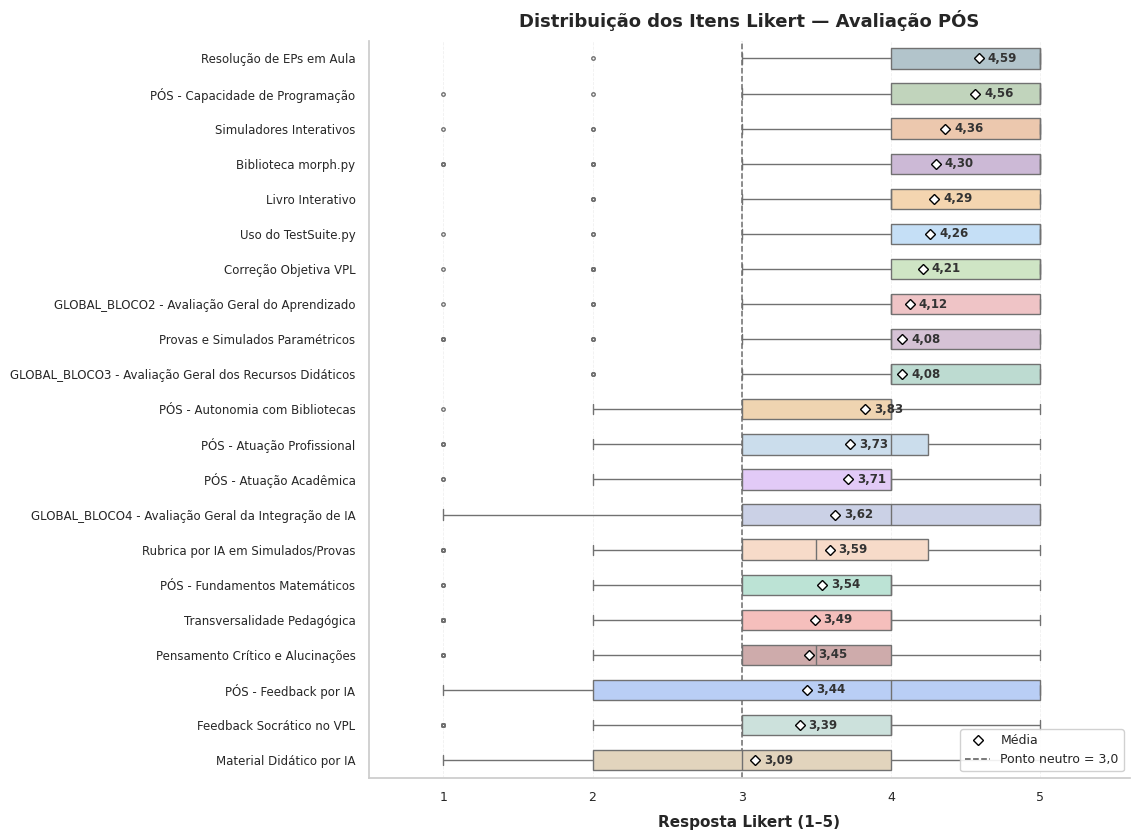

**Figura 1.2:** Distribuição das respostas dos 21 itens *Likert* do questionário PÓS, ordenados pela média decrescente. O Material Didático por IA, gerado com o *Gemini Notebook*, apresentou a pior média entre os itens analisados.


In [ ]:
# @title { display-mode: "form" }
CODIGOS_SINTESE = (
    ["Q01", "Q02", "Q03", "Q04", "Q05", "Q06", "Q07"]
    + [f"Q08_{i:02d}" for i in range(1, 11)]
    + ["Q10", "Q11", "Q12", "Q13"]
)
assert len(CODIGOS_SINTESE) == 21, f"Esperava 21 itens Likert na síntese, obtive {len(CODIGOS_SINTESE)}."


def limpar_descricao_grafico(texto):
    """Remove colchetes, emojis e espaços duplicados de um rótulo, para uso em eixo de gráfico."""
    texto = str(texto)
    texto = texto.replace("[", "").replace("]", "")
    texto = re.sub(r"[\U00010000-\U0010FFFF]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


# Monta a síntese: item, descrição, média e p-valor vs. ponto neutro (3,0),
# reaproveitando VALOR_NEUTRO já definido no chunk tbl-q08-ranking
linhas_sintese = []
for cod in CODIGOS_SINTESE:
    serie = pd.to_numeric(pos[cod], errors="coerce").dropna()
    diffs = serie - VALOR_NEUTRO
    diffs_nao_nulas = diffs[diffs != 0]
    _, p_valor = stats.wilcoxon(diffs_nao_nulas) if len(diffs_nao_nulas) > 0 else (np.nan, np.nan)
    linhas_sintese.append({
        "item": cod,
        "descricao": DESCRICOES.get(cod, cod),
        "media": serie.mean(),
        "p_vs_neutro": p_valor,
    })

df_sintese_geral = pd.DataFrame(linhas_sintese).sort_values("media", ascending=False).reset_index(drop=True)
df_sintese_geral["descricao_grafico"] = df_sintese_geral["descricao"].apply(limpar_descricao_grafico)

# Item com a pior média e itens sem evidência de diferença ao neutro — usados no texto
item_pior_media = df_sintese_geral.iloc[-1]
itens_sem_evidencia = df_sintese_geral[df_sintese_geral["p_vs_neutro"] >= 0.05]

print(f"Pior média: {item_pior_media['item']} ({item_pior_media['descricao']}) = {fmt_num_br(item_pior_media['media'])}")
if len(itens_sem_evidencia) > 0:
    print("Itens sem evidência de diferença ao ponto neutro:", ", ".join(itens_sem_evidencia["item"]))

# ------------------------------------------------------------------------------
# Dados para o boxplot (uma linha por resposta individual)
# ------------------------------------------------------------------------------
dados_boxplot = []
for _, row in df_sintese_geral.iterrows():
    respostas = pd.to_numeric(pos[row["item"]], errors="coerce").dropna()
    dados_boxplot.append(pd.DataFrame({
        "item": row["descricao_grafico"], "codigo": row["item"], "resposta": respostas,
    }))
dados_boxplot = pd.concat(dados_boxplot, ignore_index=True)

ordem_descricoes = df_sintese_geral["descricao_grafico"].tolist()
dados_boxplot["item"] = pd.Categorical(dados_boxplot["item"], categories=ordem_descricoes, ordered=True)

paleta_pastel = [
    "#AEC6CF", "#BFD8B8", "#F7C6A3", "#CDB4DB", "#FFD6A5", "#BDE0FE", "#CDEAC0",
    "#F6BDC0", "#D8BFD8", "#B8E0D2", "#F9D5A7", "#C6DEF1", "#E2C2FF", "#C7CEEA",
    "#FFDAC1", "#B5EAD7", "#FFB7B2", "#D4A5A5", "#AFCBFF", "#C9E4DE", "#E8D5B7",
]
cores_itens = dict(zip(ordem_descricoes, paleta_pastel))

fig, ax = plt.subplots(figsize=(11.5, 8.5))
sns.boxplot(
    data=dados_boxplot, y="item", x="resposta", order=ordem_descricoes,
    hue="item", palette=cores_itens, legend=False, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 5, "zorder": 10},
    width=0.58, linewidth=1.0, fliersize=2.5, ax=ax,
)
ax.axvline(x=VALOR_NEUTRO, color="#555555", linestyle="--", linewidth=1.1, alpha=0.85, zorder=1)

for i, (_, row) in enumerate(df_sintese_geral.iterrows()):
    ax.text(row["media"] + 0.06, i, f"{row['media']:.2f}".replace(".", ","),
            color=CORES["texto_medio"], fontsize=8.5, fontweight="bold", va="center", ha="left", zorder=12)

ax.set_xlim(0.5, 5.6)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Resposta Likert (1–5)", fontsize=FONTE["eixo"], fontweight="bold", labelpad=8)
ax.set_ylabel("")
ax.set_title("Distribuição dos Itens Likert — Avaliação PÓS", fontsize=FONTE["titulo"], fontweight="bold", pad=10)

marcador_media = mlines.Line2D([], [], color="white", marker="D", markerfacecolor="white",
                                markeredgecolor="black", markersize=5, label="Média")
linha_neutra_legenda = mlines.Line2D([], [], color="#555555", linestyle="--", linewidth=1.1, label="Ponto neutro = 3,0")
ax.legend(handles=[marcador_media, linha_neutra_legenda], loc="lower right",
          frameon=True, facecolor="white", framealpha=0.9, fontsize=FONTE["legenda"])

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.30)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8.5)
ax.tick_params(axis="x", labelsize=9)
estilo_eixos(ax)

plt.tight_layout()
#plt.savefig("imagens/apendice_f_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

Os resultados evidenciam três aspectos principais. Primeiro, **atividades práticas, interativas e relacionadas à programação** estiveram entre os recursos mais bem avaliados, padrão também observado nas preferências declaradas em `Q09`. Segundo, na análise pareada entre PRÉ e PÓS, **não foi identificada evidência estatisticamente significativa de mudança** em nenhuma das seis dimensões avaliadas pelo teste de *Wilcoxon*. Terceiro, a **integração transversal da IA recebeu avaliação positiva**, embora os recursos com participação direta da IA na geração de conteúdo, *feedback* ou rubricas tenham apresentado avaliações inferiores às dos recursos mais bem avaliados.

A análise longitudinal deve ser interpretada considerando o tamanho da **amostra pareada de 15 estudantes**. As diferenças identificadas nas amostras completas pelo teste de *Mann--Whitney U* representam diferenças entre os conjuntos de respondentes e, portanto, não permitem inferir evolução individual.

No Bloco 3, o teste de Friedman indicou diferenças estatisticamente significativas entre as avaliações dos dez recursos ($\chi^2(9)=189,662$, $p<0,001$), com $W=0,263$ de Kendall. A convergência entre `Q08` e `Q09` destaca a valorização de **prática guiada, programação, experimentação e interação**.

Entre os 21 itens *Likert*, o **Material Didático por IA (`Q08_02`)**, produzido com o *Gemini Notebook*, apresentou a menor média (**3,087**) e foi o **único item sem evidência estatística de diferença em relação ao ponto neutro**. Esse resultado é compatível com a hipótese exploratória de que a percepção dos estudantes dependa não apenas da presença da IA, mas também de **como ela é integrada à atividade pedagógica**. Essa interpretação, entretanto, não permite estabelecer relação causal entre a forma de utilização da IA e as avaliações observadas.

### Tabela Síntese dos Resultados Estatísticos

Como síntese quantitativa, a [Tabela 1.15](#tbl-sintese-geral) reúne os **21 itens *Likert*** dos Blocos 2, 3 e 4 do questionário PÓS, ordenados pela média decrescente. São apresentados, para cada item, a média, o desvio-padrão (DP), a mediana e o *p*-valor do teste de postos sinalizados de *Wilcoxon* para uma amostra, tendo **3,0 como ponto neutro** da escala. O nível de significância adotado foi de 5%.

Considerando **N=80** respostas válidas, **20 dos 21 itens (95,2%) apresentaram evidência estatística de avaliação superior ao ponto neutro**. A única exceção foi `Q08_02` — Material Didático por IA — cuja média foi 3,087, sem diferença estatisticamente significativa em relação a 3,0 ($p=0,710$).

A ordenação evidencia maior concentração das avaliações no conjunto de **recursos práticos e interativos**, enquanto os itens relacionados à integração transversal da IA e ao seu uso direto em determinados recursos apresentam médias mais moderadas. A tabela permite, assim, visualizar conjuntamente a distribuição das avaliações entre competências, recursos didáticos e integração da IA, sem pressupor que essas categorias constituam um único construto.

Esses resultados têm caráter **descritivo e inferencial em relação ao ponto neutro**, não permitindo estabelecer relações causais entre as características dos recursos e as avaliações atribuídas pelos estudantes.

In [ ]:
# @title { display-mode: "form" }
# --------------------------------------------------------------------------
# Classificação de bloco por item — decisão editorial (não extraível dos
# dados), no mesmo espírito de CLASSIFICACAO_IA_BLOCO3. Cobre exatamente os
# 21 itens Likert da síntese (CODIGOS_SINTESE, já validado por assert no
# chunk da fig-boxplot-sintese-likert).
# --------------------------------------------------------------------------
def classificar_bloco(cod):
    """Deriva o 'Bloco' de um item a partir do padrão do próprio código e, para
    os itens globais (Q07/Q10/Q13), do marcador GLOBAL_BLOCOx já presente no
    rótulo extraído do Forms (metadados_perguntas.json) — sem dicionário manual
    por item, só a regra de nomenclatura usada no questionário."""
    rotulo_bruto = METADADOS_PERGUNTAS.get(cod, {}).get("rotulo", "") or ""

    m = re.search(r"GLOBAL_BLOCO(\d)", rotulo_bruto)
    if m:
        destino = {"2": "Competências", "3": "Recursos Didáticos", "4": "IA Transversal"}
        return f"Global — {destino.get(m.group(1), '?')}"

    if re.fullmatch(r"Q0[1-6]", cod):
        return "Competências"
    if re.fullmatch(r"Q08_\d{2}", cod):
        return "Recursos Didáticos"
    if cod in ("Q11", "Q12"):
        return "IA Transversal"
    return "Outro"

codigos_sintese = (
    ["Q01", "Q02", "Q03", "Q04", "Q05", "Q06", "Q07"]
    + [f"Q08_{i:02d}" for i in range(1, 11)]
    + ["Q10", "Q11", "Q12", "Q13"]
)
assert len(codigos_sintese) == 21

blocos_detectados = {cod: classificar_bloco(cod) for cod in codigos_sintese}
assert "Outro" not in blocos_detectados.values(), (
    f"Item(ns) sem bloco reconhecido: {[c for c, b in blocos_detectados.items() if b == 'Outro']}"
)

linhas_sintese_geral = []
ns_sintese = set()
for cod in codigos_sintese:
    serie = pd.to_numeric(pos[cod], errors="coerce").dropna()
    ns_sintese.add(len(serie))
    diffs = serie - VALOR_NEUTRO
    diffs_nao_nulas = diffs[diffs != 0]
    _, p_valor = stats.wilcoxon(diffs_nao_nulas) if len(diffs_nao_nulas) > 0 else (np.nan, np.nan)

    linhas_sintese_geral.append({
        "Bloco": blocos_detectados[cod],
        "Item": cod,
        "Descrição resumida": DESCRICOES.get(cod, cod),
        "_media": serie.mean(),
        "DP": fmt_num_br(serie.std()),
        "Mediana": fmt_num_br(serie.median(), casas=0),
        "_p": p_valor,
    })
# ... resto do chunk igual ao anterior

if len(ns_sintese) > 1:
    print(f"Aviso: N variável entre os 21 itens da síntese -> {sorted(ns_sintese)}")
n_sintese = max(ns_sintese)

df_sintese_completa = pd.DataFrame(linhas_sintese_geral).sort_values("_media", ascending=False).reset_index(drop=True)

n_significativos = (df_sintese_completa["_p"] < 0.05).sum()
n_total_sintese = len(df_sintese_completa)
pct_significativos = n_significativos / n_total_sintese

df_sintese_completa["Item"] = df_sintese_completa["Item"].apply(lambda c: f"`{c}`")
df_sintese_completa["Média"] = df_sintese_completa["_media"].apply(fmt_num_br)
df_sintese_completa["p vs. 3,0"] = df_sintese_completa["_p"].apply(fmt_p_br)
df_sintese_completa["Sig.?"] = df_sintese_completa["_p"].apply(lambda p: "Sim" if p < 0.05 else "Não")

df_sintese_tbl = df_sintese_completa[
    ["Bloco", "Item", "Descrição resumida", "Média", "DP", "Mediana", "p vs. 3,0", "Sig.?"]
]

print(f"{n_significativos} de {n_total_sintese} itens ({pct_significativos:.1%}) com evidência de deslocamento favorável (N={n_sintese}).")

Markdown(df_sintese_tbl.to_markdown(index=False, colalign=("left", "left", "left", "center", "center", "center", "center", "center")))

20 de 21 itens (95.2%) com evidência de deslocamento favorável (N=80).


**Tabela 1.15:** Síntese estatística dos itens *Likert* dos Blocos 2, 3 e 4, ordenada pela média decrescente. Os valores de p referem-se ao teste de postos sinalizados de Wilcoxon para uma amostra, tendo 3,0 como valor de referência.


| Bloco                       | Item     | Descrição resumida                                     |  Média  |  DP   |  Mediana  |  p vs. 3,0  |  Sig.?  |
|:----------------------------|:---------|:-------------------------------------------------------|:-------:|:-----:|:---------:|:-----------:|:-------:|
| Recursos Didáticos          | `Q08_04` | Resolução de EPs em Aula                               |  4,588  | 0,650 |     5     |   <0,001    |   Sim   |
| Competências                | `Q01`    | PÓS - Capacidade de Programação                        |  4,562  | 0,760 |     5     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_03` | Simuladores Interativos                                |  4,362  | 0,846 |     5     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_05` | Biblioteca morph.py                                    |  4,300  | 1,048 |     5     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_01` | Livro Interativo                                       |  4,287  | 0,814 |     4     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_10` | Uso do TestSuite.py                                    |  4,263  | 0,938 |     5     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_09` | Correção Objetiva VPL                                  |  4,213  | 1,015 |     5     |   <0,001    |   Sim   |
| Global — Competências       | `Q07`    | GLOBAL_BLOCO2 - Avaliação Geral do Aprendizado         |  4,125  | 0,891 |     4     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_06` | Provas e Simulados Paramétricos                        |  4,075  | 1,077 |     4     |   <0,001    |   Sim   |
| Global — Recursos Didáticos | `Q10`    | GLOBAL_BLOCO3 - Avaliação Geral dos Recursos Didáticos |  4,075  | 0,823 |     4     |   <0,001    |   Sim   |
| Competências                | `Q05`    | PÓS - Autonomia com Bibliotecas                        |  3,825  | 0,925 |     4     |   <0,001    |   Sim   |
| Competências                | `Q03`    | PÓS - Atuação Profissional                             |  3,725  | 1,043 |     4     |   <0,001    |   Sim   |
| Competências                | `Q02`    | PÓS - Atuação Acadêmica                                |  3,712  | 1,009 |     4     |   <0,001    |   Sim   |
| Global — IA Transversal     | `Q13`    | GLOBAL_BLOCO4 - Avaliação Geral da Integração de IA    |  3,625  | 1,236 |     4     |   <0,001    |   Sim   |
| Recursos Didáticos          | `Q08_08` | Rubrica por IA em Simulados/Provas                     |  3,587  | 1,099 |     4     |   <0,001    |   Sim   |
| Competências                | `Q04`    | PÓS - Fundamentos Matemáticos                          |  3,538  | 1,043 |     4     |   <0,001    |   Sim   |
| IA Transversal              | `Q12`    | Transversalidade Pedagógica                            |  3,487  | 1,212 |     4     |    0,003    |   Sim   |
| IA Transversal              | `Q11`    | Pensamento Crítico e Alucinações                       |  3,450  | 1,135 |     4     |    0,001    |   Sim   |
| Competências                | `Q06`    | PÓS - Feedback por IA                                  |  3,438  | 1,330 |     4     |    0,007    |   Sim   |
| Recursos Didáticos          | `Q08_07` | Feedback Socrático no VPL                              |  3,388  | 1,248 |     4     |    0,011    |   Sim   |
| Recursos Didáticos          | `Q08_02` | Material Didático por IA                               |  3,087  | 1,361 |     3     |    0,710    |   Não   |

## 1.12 Principais Conclusões

Os resultados permitem sintetizar os principais achados da análise:

1. **Avaliação global positiva.** Os recursos didáticos apresentaram avaliação favorável, com média de **4,075** e mediana 4 em `Q10`.

2. **Diferenciação entre os recursos.** O teste de Friedman identificou diferenças estatisticamente significativas entre os dez recursos ($\chi^2(9)=189,662$, $p<0,001$), com concordância moderada segundo o W de Kendall ($W=0,263$).

3. **Predomínio de recursos práticos e interativos.** A **Resolução de EPs em Aula**, os **simuladores** e a biblioteca **`morph.py`** estiveram entre os recursos mais bem avaliados e mais frequentemente selecionados em `Q09`, evidenciando a valorização de atividades de experimentação e programação.

4. **Ausência de evidência de mudança individual.** No teste de *Wilcoxon* aplicado aos **15 estudantes pareados**, nenhuma das seis dimensões comparadas entre PRÉ e PÓS apresentou diferença estatisticamente significativa. Esse resultado deve ser considerado à luz do tamanho reduzido da amostra pareada.

5. **Percepção favorável da integração da IA.** Os três itens do Bloco 4 apresentaram avaliações estatisticamente superiores ao ponto neutro. Entretanto, os recursos com participação direta da IA na geração de conteúdo, *feedback* ou rubricas tiveram avaliações mais moderadas do que diversos recursos práticos.

6. **Coerência entre avaliações específicas e globais.** O escore médio de `Q08` apresentou correlação positiva e moderada com `Q10` ($\rho=0,519$, $p<0,001$), enquanto `Q11` e `Q12` apresentaram associação forte com `Q13` ($\rho=0,777$, $p<0,001$).

7. **Ausência de diferenças globais entre turmas.** Não foram identificadas diferenças estatisticamente significativas entre as turmas na avaliação global dos recursos (`Q10`: $p=0,095$) ou da integração da IA (`Q13`: $p=0,184$).

8. **Consistência interna adequada.** Os dez itens de `Q08` apresentaram $\alpha=0,842$. Para `Q11` e `Q12`, obteve-se $\alpha=0,786$, resultado que deve ser interpretado com cautela por se basear em apenas dois itens.

Em conjunto, os resultados indicam que a percepção dos estudantes esteve associada sobretudo à **forma de inserção dos recursos nas atividades de aprendizagem**, com destaque para práticas guiadas, experimentação e programação. A participação direta da IA, por si só, não explica as diferenças observadas entre os recursos, que também se distinguem por finalidade, formato, interação, complexidade e momento de utilização.


> ### 📝 Nota metodológica
>
> Os resultados devem ser interpretados como evidências de **diferenças, associações e padrões de percepção**, e não como demonstrações de causalidade. Em particular, as avaliações dos recursos com participação direta da IA não permitem inferir um efeito positivo ou negativo da tecnologia. Da mesma forma, diferenças entre as amostras completas PRÉ e PÓS não constituem evidência de evolução individual; para essa finalidade, foram considerados exclusivamente os estudantes pareados.

## 1.13 Avaliação de Valência das Respostas Abertas — Q14 e Q15

As questões abertas `Q14` e `Q15` são analisadas separadamente das escalas Likert por meio de **codificação temática** e **classificação de valência**. A valência global é atribuída uma única vez por resposta; a codificação temática é múltipla, permitindo que uma mesma resposta seja associada a mais de um tema.

> As categorias **POSITIVA**, **NEGATIVA**, **MISTA** e **NEUTRA** são mantidas separadas. A classificação negativa em Q15 indica crítica, limitação ou necessidade de ajuste no aspecto mencionado, não uma avaliação global da disciplina.

Os rótulos individuais são a codificação analítica documentada. A partir deles, o notebook gera automaticamente as tabelas globais e temáticas, os gráficos, os percentuais e os arquivos de auditoria, evitando a manutenção manual de resultados duplicados.

In [ ]:
# Codificação-fonte: os rótulos individuais continuam documentados manualmente;
# todas as agregações, tabelas, gráficos e arquivos de saída são automáticos.
from collections import Counter
from pathlib import Path
from IPython.display import Markdown, display

ORDEM_VALENCIA = ["POSITIVA", "NEGATIVA", "MISTA", "NEUTRA"]

q14_codes = {
    0:["A"],1:["A"],2:["A"],3:["B"],4:["A"],5:["C"],6:["A"],7:["A"],8:["A"],9:["A"],
    10:["A"],11:["C"],12:["A"],13:["C"],14:["A"],15:["A"],16:["B"],17:["B"],18:["A"],19:["A","D"],
    20:["A"],21:["D","C"],22:["B"],23:["D"],24:["A"],25:["B"],26:["A"],27:["A"],28:["A"],29:["A"],
    30:["E"],31:["A"],32:["D","B"],33:["F"],34:["D"],35:["E"],36:["A"],37:["F"],38:["D"],39:["D","A"]
}
labels_q14 = {
    "A":"Geração de material (livro/PDF/vídeos/simuladores/NotebookLM)",
    "B":"Feedback de IA nos EPs",
    "C":"Feedback/rubrica em simulados e provas",
    "D":"EPs/prática em geral (sem menção clara à IA)",
    "E":"Nenhum ganho / rejeita uso de IA",
    "F":"Não classificável / resposta não conclusiva",
}
q15_codes = {
    0:["SEB","TEMPO"],1:["MCTEST","VPL"],2:["VPL","MATERIAL"],3:["FEEDBACK"],4:["SEB"],5:["BIBLIOTECA"],6:["VPL"],7:["FEEDBACK"],8:["VPL"],9:["BIBLIOTECA","VPL"],
    10:["FEEDBACK"],11:["BIBLIOTECA","FEEDBACK"],12:["SEB","TEMPO","BIBLIOTECA"],13:["MCTEST"],14:["FEEDBACK","VPL"],15:["SEB","TEMPO","BIBLIOTECA"],16:["SEB"],17:["VPL"],18:["SEB","VPL"],19:["BIBLIOTECA"],20:["VPL"],21:["FEEDBACK"],22:["MATERIAL"],23:["NENHUM"],24:["FEEDBACK","MATERIAL"],25:["FEEDBACK","VPL"],26:["OUTRO"],27:["TEMPO","OUTRO"],28:["FEEDBACK"],29:["MATERIAL","SEB"],30:["BIBLIOTECA","OUTRO"],31:["VPL"],32:["MCTEST"],33:["FEEDBACK","BIBLIOTECA"],34:["FEEDBACK","BIBLIOTECA"],35:["SEB","TEMPO"],36:["FEEDBACK","MATERIAL"],37:["OUTRO","MATERIAL"]
}
labels_q15 = {
    "SEB":"SEB (ambiente seguro de provas)", "MCTEST":"MCTest", "TEMPO":"Tempo de prova/simulado", "FEEDBACK":"Feedback por IA", "BIBLIOTECA":"Biblioteca (morph/opencv)", "VPL":"VPL / restrição à rede da UFABC (emergente)", "MATERIAL":"Material gerado por IA (vídeos/slides/excesso) (emergente)", "NENHUM":"Nenhuma dificuldade relevante", "OUTRO":"Outro (estrutura dos EPs, conteúdo, etc.)", "F":"Não classificável / resposta não conclusiva"
}
valencia_q14 = {0:'POSITIVA',1:'POSITIVA',2:'POSITIVA',3:'POSITIVA',4:'POSITIVA',5:'POSITIVA',6:'POSITIVA',7:'POSITIVA',8:'POSITIVA',9:'POSITIVA',10:'POSITIVA',11:'POSITIVA',12:'MISTA',13:'NEUTRA',14:'POSITIVA',15:'POSITIVA',16:'POSITIVA',17:'POSITIVA',18:'MISTA',19:'POSITIVA',20:'POSITIVA',21:'POSITIVA',22:'NEUTRA',23:'POSITIVA',24:'POSITIVA',25:'POSITIVA',26:'POSITIVA',27:'POSITIVA',28:'POSITIVA',29:'POSITIVA',30:'NEGATIVA',31:'POSITIVA',32:'NEUTRA',33:'POSITIVA',34:'POSITIVA',35:'NEGATIVA',36:'POSITIVA',37:'NEGATIVA',38:'POSITIVA',39:'POSITIVA',40:'NEUTRA'}
valencia_q15 = {0:'NEGATIVA',1:'NEGATIVA',2:'NEGATIVA',3:'NEGATIVA',4:'MISTA',5:'NEUTRA',6:'NEGATIVA',7:'NEGATIVA',8:'NEGATIVA',9:'NEGATIVA',10:'NEGATIVA',11:'NEGATIVA',12:'MISTA',13:'NEGATIVA',14:'NEGATIVA',15:'MISTA',16:'NEGATIVA',17:'NEGATIVA',18:'NEGATIVA',19:'NEGATIVA',20:'NEGATIVA',21:'NEGATIVA',22:'MISTA',23:'NEUTRA',24:'NEGATIVA',25:'NEGATIVA',26:'NEGATIVA',27:'NEGATIVA',28:'NEGATIVA',29:'MISTA',30:'NEGATIVA',31:'NEGATIVA',32:'NEUTRA',33:'NEGATIVA',34:'NEGATIVA',35:'NEGATIVA',36:'NEGATIVA',37:'MISTA',38:'NEUTRA'}
override_q14 = {(12,"A"):"POSITIVA", (18,"A"):"MISTA"}
override_q15 = {(4,"SEB"):"MISTA",(12,"SEB"):"MISTA",(12,"TEMPO"):"NEGATIVA",(12,"BIBLIOTECA"):"MISTA",(15,"SEB"):"MISTA",(15,"TEMPO"):"NEGATIVA",(15,"BIBLIOTECA"):"NEGATIVA",(22,"MATERIAL"):"NEGATIVA",(29,"MATERIAL"):"NEGATIVA",(29,"SEB"):"NEGATIVA",(37,"OUTRO"):"NEGATIVA",(37,"MATERIAL"):"MISTA"}

def respostas_abertas_validas(serie):
    """Retorna apenas respostas realmente preenchidas, excluindo NaN e strings vazias."""
    serie = serie.astype("string").str.strip()
    return serie[serie.notna() & serie.ne("")].reset_index(drop=True)

config = {
    "Q14": (respostas_abertas_validas(pos["Q14"]), q14_codes, valencia_q14, override_q14, labels_q14),
    "Q15": (respostas_abertas_validas(pos["Q15"]), q15_codes, valencia_q15, override_q15, labels_q15),
}
for questao, (respostas, temas, vals, overrides, labels) in config.items():
    n = len(respostas)
    faltantes_temas = sorted(set(range(n)) - set(temas))
    extras_temas = sorted(set(temas) - set(range(n)))
    if faltantes_temas:
        print(f"Aviso — {questao}: respostas sem tema manual; atribuídas a F: {faltantes_temas}")
        temas = {i: temas.get(i, ["F"]) for i in range(n)}
        config[questao] = (respostas, temas, vals, overrides, labels)
    assert not extras_temas, f"{questao}: índices temáticos inexistentes: {extras_temas}"
    assert set(vals) == set(range(n)), f"{questao}: valência não cobre as respostas não vazias."
    assert all(v in ORDEM_VALENCIA for v in vals.values()), f"{questao}: valência inválida."
    assert all(t in labels for lista in temas.values() for t in lista), f"{questao}: tema sem rótulo."

# Uma tabela longa é a única fonte para todas as agregações posteriores.
linhas = []
for questao, (respostas, temas, vals, overrides, labels) in config.items():
    for i, resposta in respostas.items():
        for tema in temas[i]:
            linhas.append({
                "questao": questao, "resposta_id": i, "resposta": resposta,
                "tema_codigo": tema, "tema": labels[tema],
                "valencia_global": vals[i],
                "valencia_tema": overrides.get((i, tema), vals[i]),
                "override_aplicado": (i, tema) in overrides,
            })
df_codificacao = pd.DataFrame(linhas)

# Tabela global: uma linha por resposta, sem dupla contagem de temas.
df_global_n = (df_codificacao.drop_duplicates(["questao", "resposta_id"])
    .pivot_table(index="questao", columns="valencia_global", values="resposta_id", aggfunc="count", fill_value=0)
    .reindex(columns=ORDEM_VALENCIA, fill_value=0))
df_global_n["Total"] = df_global_n.sum(axis=1)
df_global = df_global_n.copy()
for col in ORDEM_VALENCIA:
    df_global[col] = [f"{n} ({n/t:.1%})" for n, t in zip(df_global_n[col], df_global_n["Total"])]
df_global = df_global.reset_index().rename(columns={"questao":"Questão", "POSITIVA":"Positiva", "NEGATIVA":"Negativa", "MISTA":"Mista", "NEUTRA":"Neutra"})

# Tabelas temáticas: uma linha por menção, portanto os totais podem exceder o número de respostas.
def tabela_temas(questao, refinada=False):
    coluna = "valencia_tema" if refinada else "valencia_global"
    sub = df_codificacao[df_codificacao.questao == questao]
    tabela = pd.crosstab(sub["tema"], sub[coluna]).reindex(columns=ORDEM_VALENCIA, fill_value=0)
    tabela["Total"] = tabela.sum(axis=1)
    return tabela.sort_values("Total", ascending=False).reset_index().rename(columns={"tema":"Categoria", "POSITIVA":"Positiva", "NEGATIVA":"Negativa", "MISTA":"Mista", "NEUTRA":"Neutra"})

df_temas_q14 = tabela_temas("Q14", refinada=True)
df_temas_q15 = tabela_temas("Q15", refinada=True)
df_frequencia_q14 = df_codificacao[df_codificacao.questao == "Q14"].groupby("tema").size().sort_values(ascending=False).rename("Menções").reset_index().rename(columns={"tema":"Categoria"})
df_frequencia_q15 = df_codificacao[df_codificacao.questao == "Q15"].groupby("tema").size().sort_values(ascending=False).rename("Menções").reset_index().rename(columns={"tema":"Categoria"})

# Saídas tabulares automáticas para auditoria e reaproveitamento.
PASTA_SAIDA = Path("resultados_valencia")
PASTA_SAIDA.mkdir(exist_ok=True)
df_codificacao.to_csv(PASTA_SAIDA / "respostas_codificadas_final.csv", index=False, encoding="utf-8-sig")
df_global.to_csv(PASTA_SAIDA / "valencia_global.csv", index=False, encoding="utf-8-sig")
df_temas_q14.to_csv(PASTA_SAIDA / "valencia_por_categoria_q14.csv", index=False, encoding="utf-8-sig")
df_temas_q15.to_csv(PASTA_SAIDA / "valencia_por_categoria_q15.csv", index=False, encoding="utf-8-sig")

print(f"Codificação validada: {len(config['Q14'][0])} respostas em Q14 e {len(config['Q15'][0])} em Q15.")
print(f"Menções temáticas: {len(df_codificacao[df_codificacao.questao == 'Q14'])} em Q14 e {len(df_codificacao[df_codificacao.questao == 'Q15'])} em Q15.")


In [ ]:
# Tabelas e gráficos desta seção são gerados exclusivamente a partir de df_codificacao.

def exibir_tabela(df, titulo):
    display(Markdown(f"#### {titulo}"))
    display(df)

exibir_tabela(df_global, "Distribuição global da valência por resposta")
exibir_tabela(df_temas_q14, "Valência por categoria temática — Q14")
exibir_tabela(df_temas_q15, "Valência por categoria temática — Q15")

# Gráfico 1: valência global, comparando as perguntas apenas descritivamente.
fig, ax = plt.subplots(figsize=(10, 4.8))
base = np.zeros(len(df_global_n))
for val, cor in zip(ORDEM_VALENCIA, [CORES["aprovado"], CORES["outlier"], CORES["efeito_medio"], CORES["neutro"]]):
    valores = df_global_n[val].to_numpy()
    ax.bar(df_global_n.index, valores, bottom=base, label=val.capitalize(), color=cor)
    base += valores
for i, total in enumerate(df_global_n["Total"]):
    ax.text(i, total + 0.5, f"n={total}", ha="center", fontsize=FONTE["texto"])
ax.set_title("Valência global das respostas abertas", loc="left", fontsize=FONTE["titulo"], fontweight="bold")
ax.set_ylabel("Número de respostas")
ax.legend(ncol=4, frameon=False)
estilo_eixos(ax)
fig.tight_layout()
plt.show()

# Gráficos 2 e 3: distribuição temática refinada, com contagens e rótulos legíveis.
def grafico_temas(df, questao, cor, titulo):
    plot = df.sort_values("Total", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.48 * len(plot) + 1.5)))
    ax.barh(plot["Categoria"], plot["Total"], color=cor)
    for y, total in enumerate(plot["Total"]):
        ax.text(total + 0.15, y, str(total), va="center", fontsize=FONTE["texto"])
    ax.set_title(titulo, loc="left", fontsize=FONTE["titulo"], fontweight="bold")
    ax.set_xlabel("Menções temáticas (codificação múltipla)")
    estilo_eixos(ax)
    fig.tight_layout()
    plt.show()

grafico_temas(df_temas_q14, "Q14", CORES["aprovado"], "Q14 — Valência por tema")
grafico_temas(df_temas_q15, "Q15", CORES["outlier"], "Q15 — Valência por tema")

n_mistas_q14 = int((df_global_n.loc["Q14", "MISTA"] if "Q14" in df_global_n.index else 0))
n_mistas_q15 = int((df_global_n.loc["Q15", "MISTA"] if "Q15" in df_global_n.index else 0))
n_overrides = int(df_codificacao["override_aplicado"].sum())
texto = f"""
### Síntese automática e observações metodológicas

Foram analisadas **{int(df_global_n.loc['Q14', 'Total'])} respostas não vazias em Q14** e **{int(df_global_n.loc['Q15', 'Total'])} em Q15**. A valência global foi calculada uma única vez por resposta; já as tabelas temáticas utilizam codificação múltipla, de modo que uma resposta pode contribuir para mais de uma categoria. Foram aplicados **{n_overrides} refinamentos por tema** em respostas cuja valência global era insuficiente para representar todos os temas mencionados.

Em Q14, a distribuição é orientada à identificação de ganhos percebidos com o uso de IA. Em Q15, a valência negativa deve ser interpretada como indicação de dificuldade, limitação ou necessidade de ajuste no aspecto mencionado, e **não como avaliação global negativa da disciplina**. As duas perguntas possuem finalidades distintas e não devem ser comparadas como medidas diretas de satisfação.

A codificação individual permanece interpretativa e manual, mas todas as contagens, percentuais, tabelas, gráficos e arquivos CSV desta seção são derivados automaticamente de uma única tabela longa (`df_codificacao`).
"""
display(Markdown(texto))


### 1.13.1 Observações metodológicas e auditabilidade

A classificação global e o refinamento por tema possuem caráter interpretativo. Não houve segundo codificador independente nem cálculo de concordância intercodificadores; portanto, os resultados devem ser lidos como uma codificação analítica documentada. As frequências são descritivas e não devem ser extrapoladas para a população de estudantes.

A tabela longa `df_codificacao` registra cada par `(questão, resposta, tema)`, incluindo a resposta, a valência global, a valência temática refinada e a indicação de ajuste. Os arquivos CSV são criados automaticamente na pasta `resultados_valencia/` durante a execução do notebook.

## Referências do Capítulo


CONOVER, W. J. **Practical Nonparametric Statistics**. New York, John Wiley \& Sons, 1971.

CRONBACH, Lee J. **Coefficient Alpha and the Internal Structure of Tests**. 1951.

DUNN, Olive Jean. **Multiple Comparisons among Means**. 1961.

FRIEDMAN, Milton. **The Use of Ranks to Avoid the Assumption of Normality Implicit in the Analysis of Variance**. 1937.

KENDALL, M. G. **The Treatment of Ties in Ranking Problems**. 1945.

KRUSKAL, William H.; WALLIS, W. Allen. **Use of Ranks in One-Criterion Variance Analysis**. 1952.

MANN, Henry B.; WHITNEY, Donald R. **On a Test of Whether One of Two Random Variables Is Stochastically Larger than the Other**. 1947.

SPEARMAN, Charles. **The Proof and Measurement of Association between Two Things**. 1904.

WILCOXON, Frank. **Individual Comparisons by Ranking Methods**. 1945.

ZAMPIROLLI, Francisco de Assis *et al*. **Intelligent Feedback for Individualized Introductory Programming Exercises**. 2026.